### **NOTEBOOK 03: SAGEMAKER PIPELINE WITH POST-PIPELINE MLFLOW APP LOGGING**
#### **TEAM 04 STUDENT 3 - TING ENG KIAT (S403)**
#### **Jupyter Notebook Version: 26 August 2026**
#### **Model B - Multilayer Perceptron (MLP)**

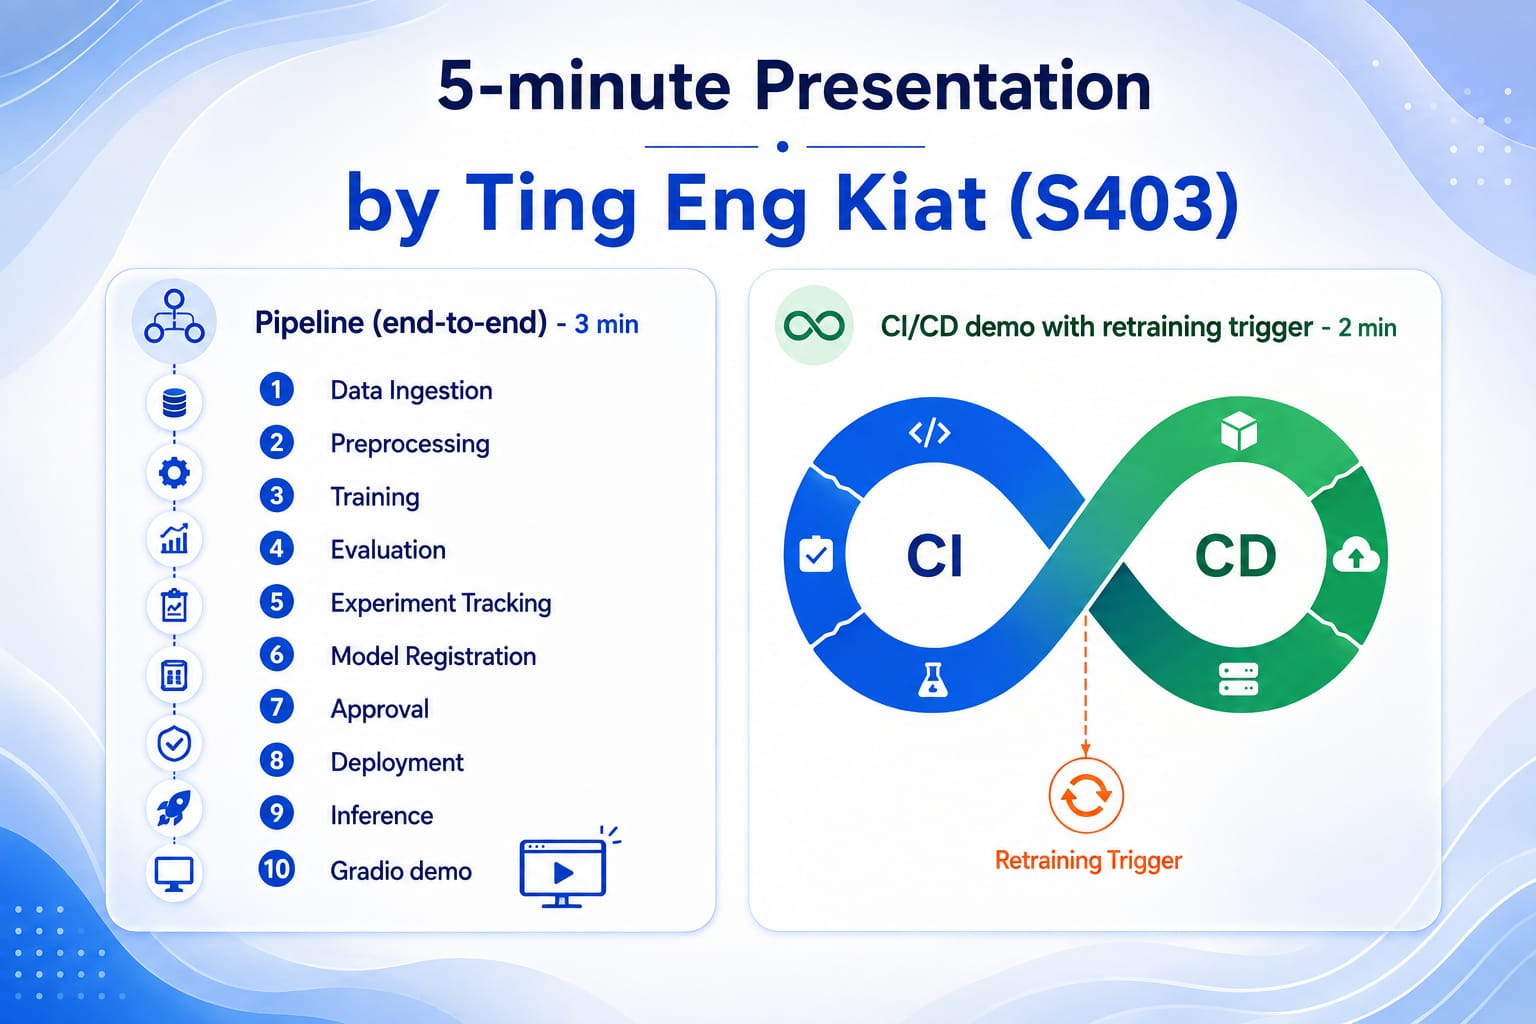

In [1]:
# INSTALL/UPGRADE SAGEMAKER, BOTO3, BOTOCORE, MLFLOW, SAGEMAKER-MLFLOW PACKAGES
# After running, restart the kernel before continuing if packages were upgraded.
%pip install --upgrade "sagemaker>=2,<3" boto3 botocore mlflow sagemaker-mlflow


  Using cached sagemaker-2.257.6-py3-none-any.whl.metadata (19 kB)


  Using cached attrs-25.4.0-py3-none-any.whl.metadata (10 kB)


  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pathos-0.3.5-py3-none-any.whl.metadata (11 kB)


  Using cached sagemaker_core-1.0.78-py3-none-any.whl.metadata (4.9 kB)


  Using cached prettytable-3.18.0-py3-none-any.whl.metadata (37 kB)


...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━ 12/13 [mlflow]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [mlflow]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
aiobotocore 3.8.0 requires botocore<1.43.47,>=1.43.3, but you have botocore 1.43.80 which is incompatible.
autogluon-common 1.5.0 requires pyarrow<21.0.0,>=7.0.0, but you have pyarrow 21.0.0 which is incompatible.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
sagemaker-mlops 1.12.0 requires sagemaker-core>=2.12.0, but you have sagemaker-core 1.0.78 which is inco

Note: you may need to restart the kernel to use updated packages.


### **STEP 01: CONFIGURATION**

In [1]:
import boto3
import sagemaker
import json
import os
import time
from pathlib import Path

# ----------------------------
# AWS / SageMaker setup
# ----------------------------
session = sagemaker.Session()
role    = sagemaker.get_execution_role()
region  = boto3.Session().region_name

# Use the ITI113 course bucket and team prefix.
# This matches the team execution role S3 policy, e.g.:
# s3://nyp-26s1-iti113/iti113/team40/
BUCKET  = "nyp-26s1-iti113"

# Change these for the current student/profile.
TEAM_ID = "team04"
STUDENT_ID = "s403"

COURSE = "ITI113"
SEMESTER = "26S1"
PROJECT_NAME = "credit-card-fraud-detection"

PREFIX  = f"iti113/{TEAM_ID}/data/{PROJECT_NAME}"

# Instance types.
# If ml.m5.large quota is 0, change these to an approved available training/processing type.
# For ITI113, keep Studio spaces on ml.t3.medium and use SageMaker jobs for training/processing.
PROCESSING_INSTANCE_TYPE = "ml.m5.large"
TRAINING_INSTANCE_TYPE   = "ml.m5.large"

# ----------------------------
# SageMaker Serverless MLflow App setup
# ----------------------------
# Preferred:
# 1. Team-level config copied/shared from Notebook 01A:
#       mlflow_app_config_team40.json
# 2. Student-specific config from Notebook 01A:
#       mlflow_app_config_team40_s4002.json
# 3. Any local config matching this team:
#       mlflow_app_config_team40_*.json
#
# Important:
# Do not use another team's MLflow ARN. With team-level IAM
# restriction, wrong-team access should fail with 403.
# ----------------------------

TEAM_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}.json")
STUDENT_CONFIG_FILE = Path(f"mlflow_app_config_{TEAM_ID}_{STUDENT_ID}.json")

config_candidates = [
    TEAM_CONFIG_FILE,
    STUDENT_CONFIG_FILE,
    *sorted(Path(".").glob(f"mlflow_app_config_{TEAM_ID}_*.json")),
]

MLFLOW_APP_ARN = None
MLFLOW_EXPERIMENT_NAME = f"{COURSE}/{TEAM_ID}/Experiment-01"
mlflow_config = {}
config_used = None

for config_file in config_candidates:
    if config_file.exists():
        mlflow_config = json.loads(config_file.read_text(encoding="utf-8"))
        MLFLOW_APP_ARN = (
            mlflow_config.get("MLFLOW_APP_ARN")
            or mlflow_config.get("mlflow_app_arn")
            or mlflow_config.get("arn")
        )
        MLFLOW_EXPERIMENT_NAME = (
            mlflow_config.get("EXPERIMENT_NAME")
            or mlflow_config.get("experiment_name")
            or MLFLOW_EXPERIMENT_NAME
        )
        MODEL_DEVELOPER_ID = mlflow_config.get("STUDENT_ID") or mlflow_config.get("student_id")
        config_used = config_file
        break

# Fallback for classroom testing only.
# Update this to your team's MLflow App ARN from Notebook 01A if the config file
# is not available in this Studio workspace.
DEFAULT_MLFLOW_APP_ARN = (
    "arn:aws:sagemaker:ap-southeast-1:044528205969:"
    "mlflow-app/app-L5IMA5YSBDTY"
)

if MLFLOW_APP_ARN is None:
    MLFLOW_APP_ARN = DEFAULT_MLFLOW_APP_ARN
    print(
        "[WARNING] No local MLflow config file found. "
        "Using DEFAULT_MLFLOW_APP_ARN. Make sure this ARN belongs to your own team."
    )
else:
    print(f"Loaded MLflow App config from {config_used}")

# Validate config team, if present.
config_team_id = mlflow_config.get("TEAM_ID") or mlflow_config.get("team_id")
if config_team_id and config_team_id != TEAM_ID:
    raise ValueError(
        f"Config file team mismatch: config TEAM_ID={config_team_id}, notebook TEAM_ID={TEAM_ID}. "
        "Do not use another team's MLflow config."
    )

# ----------------------------
# Safety check for team-level MLflow restriction
# ----------------------------
# The selected MLflow App must have ResourceTag/TeamId = TEAM_ID.
# If a student accidentally uses another team's ARN, this should either:
# - fail with AccessDenied / 403 due to IAM restriction, or
# - fail this explicit validation before logging.
# ----------------------------

sm_for_mlflow = boto3.client("sagemaker", region_name=region)

try:
    tag_response = sm_for_mlflow.list_tags(ResourceArn=MLFLOW_APP_ARN)
    mlflow_app_tags = {t["Key"]: t["Value"] for t in tag_response.get("Tags", [])}

    print("MLflow App tags:")
    for k, v in mlflow_app_tags.items():
        print(f"  {k}: {v}")

    app_team_id = mlflow_app_tags.get("TeamId")
    if app_team_id != TEAM_ID:
        raise PermissionError(
            f"MLflow App TeamId tag mismatch. App TeamId={app_team_id}, notebook TEAM_ID={TEAM_ID}. "
            "Do not log to another team's MLflow App."
        )

    print(f"[OK] MLflow App tag TeamId={app_team_id} matches notebook TEAM_ID={TEAM_ID}")

except Exception as e:
    print("\n[ERROR] Could not validate MLflow App team tag.")
    print("This usually means one of the following:")
    print("1. The MLflow App ARN belongs to another team and IAM correctly blocked access.")
    print("2. The MLflow App is missing the TeamId tag.")
    print("3. The current role lacks permission to list tags for this MLflow App.")
    print(type(e).__name__, e)
    raise

# Optional: store for downstream cells and subprocesses.
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_APP_ARN
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT_NAME


# ----------------------------
# MLflow App UI link helpers
# ----------------------------
# MLflow may print generic links such as:
# https://mlflow.sagemaker.ap-southeast-1.app.aws/#/...
# Those links are not presigned and may show a permission/session error.
# Use these helpers to generate a fresh presigned SageMaker MLflow App URL
# and append the experiment/run fragment.

def create_mlflow_app_presigned_url(fragment: str = "") -> str:
    sm_for_mlflow = boto3.client("sagemaker", region_name=region)
    response = sm_for_mlflow.create_presigned_mlflow_app_url(
        Arn=MLFLOW_APP_ARN
    )

    base_url = response.get("AuthorizedUrl") or response.get("Url")

    if not base_url:
        raise RuntimeError(
            "create_presigned_mlflow_app_url did not return AuthorizedUrl or Url. "
            f"Response: {response}"
        )

    # Remove any existing fragment before appending our own MLflow UI route.
    base_url = base_url.split("#", 1)[0]

    if fragment:
        return base_url + "#" + fragment.lstrip("#")

    return base_url


def print_mlflow_presigned_links(experiment_id=None, run_id=None):
    if experiment_id is not None:
        experiment_url = create_mlflow_app_presigned_url(
            f"/experiments/{experiment_id}"
        )
        print("Presigned MLflow experiment URL:")
        print(experiment_url)

    if experiment_id is not None and run_id is not None:
        run_url = create_mlflow_app_presigned_url(
            f"/experiments/{experiment_id}/runs/{run_id}"
        )
        print("\nPresigned MLflow run URL:")
        print(run_url)

PIPELINE_NAME       = f"iti113-{TEAM_ID}-credit-card-fraud-detection"
MODEL_PACKAGE_GROUP = f"{TEAM_ID}-credit-card-fraud-detection"
ENDPOINT_NAME       = f"iti113-{TEAM_ID}-credit-card-fraud-detection-b"
QUALITY_GATE_AUC    = 0.35

RAW_DATA_URI  = f"s3://{BUCKET}/{PREFIX}/raw/fraudTest.csv"
PIPELINE_ROOT = f"s3://{BUCKET}/{PREFIX}/pipeline"

# Store the pipeline source files in S3 first, then download them into a clean local folder.
SCRIPTS_S3_PREFIX = f"{PREFIX}/pipeline_src"
SCRIPTS_S3_URI    = f"s3://{BUCKET}/{SCRIPTS_S3_PREFIX}"

LOCAL_PIPELINE_SRC = "pipeline_src"


print(f"Pipeline                : {PIPELINE_NAME}")
print(f"Bucket                  : {BUCKET}")
print(f"Team prefix             : {PREFIX}")
print(f"Semester                : {SEMESTER}")
print(f"Region                  : {region}")
print(f"SageMaker role          : {role}")
print(f"MLflow App ARN          : {MLFLOW_APP_ARN}")
print(f"MLflow experiment       : {MLFLOW_EXPERIMENT_NAME}")
print(f"Pipeline source S3 URI  : {SCRIPTS_S3_URI}")
print(f"Local pipeline source   : {LOCAL_PIPELINE_SRC}")


sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml


/opt/conda/lib/python3.12/site-packages/sagemaker/__init__.py:86: SageMakerV2DeprecationWarning: You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation()
You are using the SageMaker Python SDK v2, which is on path of deprecation. v3 is the actively developed major version.
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Loaded MLflow App config from mlflow_app_config_team04_s403.json
MLflow App tags:
  Semester: 26S1
  sagemaker:domain-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:domain/d-5q0cdlsfisve
  ProjectName: credit-card-fraud-detection
  sagemaker:space-arn: arn:aws:sagemaker:ap-southeast-1:044528205969:space/d-5q0cdlsfisve/team04-shared
  Course: ITI113
  TeamId: team04
  CreatedByNotebook: ModelB
  StudentId: s401
[OK] MLflow App tag TeamId=team04 matches notebook TEAM_ID=team04
Pipeline                : iti113-team04-credit-card-fraud-detection
Bucket                  : nyp-26s1-iti113
Team prefix             : iti113/team04/data/credit-card-fraud-detection
Semester                : 26S1
Region                  : ap-southeast-1
SageMaker role          : arn:aws:iam::044528205969:role/SageMakerExecutionRole-ITI113-Team04
MLflow App ARN          : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow experiment       : ITI113/team04/Experiment-01
Pipeline sour

### **STEP 02: PRECHECK SAGEMAKER MLFLOW APP CONNECTION**

In [2]:
import mlflow
import time

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

with mlflow.start_run(run_name=f"{TEAM_ID}_pipeline_notebook_precheck_{int(time.time())}") as run:
    mlflow.set_tags({
        "course": "ITI113",
        "semester": SEMESTER,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "dataset": "heart-disease",
        "run_type": "sagemaker_pipeline_precheck",
        "tracking_backend": "sagemaker_mlflow_app",
        "mlflow_app_arn": MLFLOW_APP_ARN,
    })
    mlflow.log_param("source", "notebook_03_precheck")
    mlflow.log_metric("connection_success", 1)

    precheck_run_id = run.info.run_id
    precheck_experiment_id = run.info.experiment_id

print("SageMaker MLflow App precheck completed.")
print("MLflow App ARN:", MLFLOW_APP_ARN)
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Experiment ID:", precheck_experiment_id)
print("Run ID:", precheck_run_id)
print("\nIgnore any generic mlflow.sagemaker.app.aws link printed by MLflow above.")
print("Use the presigned links below instead:")
print_mlflow_presigned_links(
    experiment_id=precheck_experiment_id,
    run_id=precheck_run_id
)


🏃 View run team04_pipeline_notebook_precheck_1787736733 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/09c4dc3516904acc84cac71cc4ae9239
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2
SageMaker MLflow App precheck completed.
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
Experiment: ITI113/team04/Experiment-01
Experiment ID: 2
Run ID: 09c4dc3516904acc84cac71cc4ae9239

Ignore any generic mlflow.sagemaker.app.aws link printed by MLflow above.
Use the presigned links below instead:


Presigned MLflow experiment URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Iks3RFBIWCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDE2SEFvLzJyMktXNEpKRHFaSVAwUmFuS2o2dXB4MVowUFJjWmR3c1RmdllBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGc1ZUUm9lWGcxU0djNWExbHZPWGRzTkhoUVlVOW9TM0pCWjBrelkyeDZMMGMwY2tJeFVsRlljeTlNVFVkS1Z6SkhNVlZZTkVOWWFGcDFWVFI2YTNOQlVUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFZb1RHVUgzakZXajJGR0JSR2lucnNRQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF3OXZBMzNnT3oycDFLR2RXZ0NBUkNBT3pNNmJIelBBUk1KcFB1OWhabU5Qc1FoWk1PK1luOFpCSGxtOWNodldzOGFpU0lPcWlYV0tMV2RCakpmd216MXBXYWM5MVZPdk45TzZYdnBBZ0FBRUFCUFIrZjV5L1JiV1pITC9kNmxpSXpjRU9vYlFWTlFRUWdMSEpGUEM5cFpnWitmaGJVRHBTV2


Presigned MLflow run URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IllaTlpJSCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNFRVZ00vRm5uSzJ2N1lLVDNSd2dNTXJRUkFUN2RzemV2aWdOaEpWZFFEMzhBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFNGNqUnJNRGd2V0VGeE9FbENlRzlpYVVkRGVVbzBjMUZ4ZDBnNFZYVnFjVkkwZGxrclduaE5SSFJUUlZwc1oyaEljbkkzTmxaamVsZHVaRGh6WmxsSGR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFjWFRsYU1IMHMrWlhBTU5lWVpaVDlVQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF3a2ZsQXQxSHUvMnQ3eVIyRUNBUkNBTzZBam9IN1kyTnVCb0VwbDNqVXliTHJ0U3A5ZmxNUWxSL0gxcG1sTU1qNEl0NHNuUkhXaFpERzljK2dnMXVEQU5ZeEFZUkhGbFBOU1ZnR2dBZ0FBRUFDa2VqWU9sR1JBRGpueXpyOWNINGwwY21neW9lWmlVL1Y3RGJyVjRKSVhUUjd2a0FMKzBTcHV1ZVlC

### **STEP 03: WRITE PIPELINE SCRIPTS**

In [3]:
os.makedirs('src', exist_ok=True)
print('src/ directory ready')


src/ directory ready


In [4]:
%%writefile src/requirements.txt
scikit-learn==1.7.2

Writing src/requirements.txt


In [5]:
%%writefile src/preprocess.py
"""SageMaker Processing Job — Model B (Vanitha, MLP track): feature engineering,
StandardScaler + OneHotEncoder fitting, train/valid/test split.
Ported from model developer B's team0401_Vanitha_Final_Model_B_Retrain_Pipeline_v1_4.ipynb
(Sections 2-5), so preprocessing produces exactly the fields the new training/inference
code expects.
NOTE: RAW_ENGINEERED_COLUMNS / CONTINUOUS_FEATURES / PASSTHROUGH_FEATURES are not sourced
from m03_feature_columns.json (not provided) -- they are inferred from the retrain notebook's
own code and the "13 raw engineered columns" count confirmed in its Section 3 Findings.
Confirm against the manifest with the model developer when available.
"""
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn==1.7.2"])

import argparse
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RAW_ENGINEERED_COLUMNS = [
    "amt", "amt_log", "category", "city_pop", "age",
    "trans_hour_sin", "trans_hour_cos", "day_of_week", "is_weekend", "gender_binary",
    "txn_velocity_1h", "txn_velocity_6h", "txn_velocity_24h",
]
CONTINUOUS_FEATURES = [
    "amt_log", "age", "city_pop", "txn_velocity_1h", "txn_velocity_6h", "txn_velocity_24h",
]
PASSTHROUGH_FEATURES = ["amt", "trans_hour_sin", "trans_hour_cos", "day_of_week", "is_weekend", "gender_binary"]
VELOCITY_WINDOWS = {"txn_velocity_1h": "1h", "txn_velocity_6h": "6h", "txn_velocity_24h": "24h"}

def add_base_features(data):
    x = data.copy()
    x["trans_date_trans_time"] = pd.to_datetime(x["trans_date_trans_time"], errors="coerce")
    x["dob"] = pd.to_datetime(x["dob"], errors="coerce")

    x["age"] = x["trans_date_trans_time"].dt.year - x["dob"].dt.year
    before_birthday = (
        (x["trans_date_trans_time"].dt.month < x["dob"].dt.month)
        | (
            (x["trans_date_trans_time"].dt.month == x["dob"].dt.month)
            & (x["trans_date_trans_time"].dt.day < x["dob"].dt.day)
        )
    )
    x["age"] -= before_birthday.astype(int)

    x["amt_log"] = np.log1p(x["amt"].clip(lower=0))

    hour = x["trans_date_trans_time"].dt.hour
    x["trans_hour_sin"] = np.sin(2 * np.pi * hour / 24)
    x["trans_hour_cos"] = np.cos(2 * np.pi * hour / 24)

    x["day_of_week"] = x["trans_date_trans_time"].dt.dayofweek
    x["is_weekend"] = (x["day_of_week"] >= 5).astype(int)

    x["gender_binary"] = x["gender"].map({"F": 0, "M": 1})
    return x

def add_velocity_features(data, windows):
    x = data.copy()
    x_sorted = x.sort_values(["cc_num", "trans_date_trans_time"]).set_index("trans_date_trans_time")
    for col_name, window in windows.items():
        counts = (
            x_sorted.groupby("cc_num")["amt"]
            .rolling(window, closed="left")
            .count()
            .fillna(0)
        )
        x_sorted[col_name] = counts.values
    x_sorted = x_sorted.reset_index()
    velocity_cols = list(windows.keys())
    return x.merge(x_sorted[["trans_num"] + velocity_cols], on="trans_num", how="left")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--test-size", type=float, default=0.20)
    parser.add_argument("--valid-size", type=float, default=0.25)
    parser.add_argument("--random-state", type=int, default=42)
    args = parser.parse_args()

    base_dir = "/opt/ml/processing"
    df = pd.read_csv(f"{base_dir}/input/fraudTest.csv")

    df = add_base_features(df)
    df = add_velocity_features(df, VELOCITY_WINDOWS)

    keep_cols = RAW_ENGINEERED_COLUMNS + ["is_fraud"]
    model_df = (
        df[keep_cols]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .reset_index(drop=True)
    )

    X = model_df[RAW_ENGINEERED_COLUMNS]
    y = model_df["is_fraud"].astype(int)

    X_dev, X_test, y_dev, y_test = train_test_split(
        X, y, test_size=args.test_size, stratify=y, random_state=args.random_state
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_dev, y_dev, test_size=args.valid_size, stratify=y_dev, random_state=args.random_state
    )

    scaler = StandardScaler()
    scaler.fit(X_train[CONTINUOUS_FEATURES])

    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(X_train[["category"]])
    ohe_columns = [f"category_{c}" for c in ohe.categories_[0]]

    out_dir = Path(base_dir) / "output"
    for name, Xdf, ydf in [("train", X_train, y_train), ("valid", X_valid, y_valid), ("test", X_test, y_test)]:
        Xdf[RAW_ENGINEERED_COLUMNS].assign(is_fraud=ydf.values).to_csv(out_dir / f"{name}.csv", index=False)

    preprocessing_bundle = {
        "scaler": scaler,
        "ohe": ohe,
        "continuous_features": CONTINUOUS_FEATURES,
        "ohe_columns": ohe_columns,
        "passthrough_features": PASSTHROUGH_FEATURES,
        "raw_engineered_columns": RAW_ENGINEERED_COLUMNS,
    }
    joblib.dump(preprocessing_bundle, out_dir / "modelb_preprocessing_bundle.joblib")

    print("Preprocessing complete.")
    print(f"Train: {len(X_train)} | Valid: {len(X_valid)} | Test: {len(X_test)}")
    print(f"Category levels: {len(ohe_columns)} -> {ohe_columns}")

Writing src/preprocess.py


In [6]:
%%writefile src/feature_transformer.py
"""Shared feature-transform class for Model B (MLP track).
Defined in its own module — not inside train.py or inference.py — so that when the
fitted sklearn.Pipeline is saved with joblib/pickle in train.py and reloaded in
inference.py, Python resolves this class from the same module path
(feature_transformer.M03FeatureTransformer) in both places. If this class were
defined inline in train.py instead, pickle would record it as belonging to
train.py's own run context, and inference.py would fail to unpickle it.
Copied verbatim (transform logic) from model developer B's
team0401_Vanitha_Final_Model_B_Retrain_Pipeline_v1_4.ipynb, Section 5.
"""

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin


class M03FeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, scaler, ohe, continuous_features, ohe_columns, passthrough_features):
        self.scaler = scaler
        self.ohe = ohe
        self.continuous_features = continuous_features
        self.ohe_columns = ohe_columns
        self.passthrough_features = passthrough_features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        scaled = pd.DataFrame(
            self.scaler.transform(X[self.continuous_features]),
            columns=self.continuous_features,
            index=X.index,
        )
        encoded = pd.DataFrame(
            self.ohe.transform(X[['category']]),
            columns=self.ohe_columns,
            index=X.index,
        )
        passthrough = X[self.passthrough_features].reset_index(drop=True)
        result = pd.concat(
            [scaled.reset_index(drop=True), encoded.reset_index(drop=True), passthrough],
            axis=1,
        )
        result.index = X.index
        return result

    def get_feature_names_out(self, input_features=None):
        return np.array(self.continuous_features + self.ohe_columns + self.passthrough_features)

Writing src/feature_transformer.py


In [7]:
%%writefile src/train.py
"""SageMaker Training Job — Model B (Vanitha, MLP track): trains MLPClassifier wrapped in a
feature-transform Pipeline, threshold selection, artifact export.
Hyperparameters are Vanitha's locked final MLP config (team0401_Vanitha_Final_Model_B_Retrain_Pipeline_v1_4.ipynb,
Section 6) -- a snapshot from her hyperparameter search, not meant to be re-tuned per pipeline
run, so hardcoded here rather than exposed as CLI arguments (matching her own retrain notebook).
The classifier__sample_weight line below is copied FAITHFULLY from her Section 6 code, unchanged,
even though scikit-learn's MLPClassifier.fit() does not accept a sample_weight argument -- if this
raises a TypeError when run, that is evidence her own code does not execute as written, not
something altered on the MLOps side. See conversation notes before "fixing" this.
Saves one artifact: modelb_pipeline.joblib (feature_transformer.M03FeatureTransformer + MLPClassifier,
as one fitted sklearn.Pipeline) plus modelb_deployment_contract.json.
"""
import argparse
import json
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, confusion_matrix, precision_recall_curve
)
from feature_transformer import M03FeatureTransformer

# Locked final MLP hyperparameters (Final Model B, Section 4a) -- snapshot, not re-tuned here.
FINAL_MLP_PARAMS = {
    "hidden_layer_sizes": (128, 64),
    "activation": "relu",
    "solver": "adam",
    "alpha": 0.01,
    "learning_rate_init": 0.001,
    "max_iter": 200,
    "early_stopping": True,
    "n_iter_no_change": 10,
    "validation_fraction": 0.1,
}

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--random-state", type=int, default=42)
    parser.add_argument("--train", type=str, default=os.environ.get("SM_CHANNEL_TRAIN"))
    parser.add_argument("--valid", type=str, default=os.environ.get("SM_CHANNEL_VALID"))
    parser.add_argument("--test", type=str, default=os.environ.get("SM_CHANNEL_TEST"))
    parser.add_argument("--preprocessor", type=str, default=os.environ.get("SM_CHANNEL_PREPROCESSOR"))
    parser.add_argument("--sm-model-dir", type=str, default=os.environ.get("SM_MODEL_DIR"))
    args = parser.parse_args()

    train_df = pd.read_csv(os.path.join(args.train, "train.csv"))
    valid_df = pd.read_csv(os.path.join(args.valid, "valid.csv"))
    test_df = pd.read_csv(os.path.join(args.test, "test.csv"))

    bundle = joblib.load(os.path.join(args.preprocessor, "modelb_preprocessing_bundle.joblib"))
    raw_cols = bundle["raw_engineered_columns"]

    X_train, y_train = train_df[raw_cols], train_df["is_fraud"].astype(int)
    X_valid, y_valid = valid_df[raw_cols], valid_df["is_fraud"].astype(int)
    X_test, y_test = test_df[raw_cols], test_df["is_fraud"].astype(int)

    feature_transformer = M03FeatureTransformer(
        scaler=bundle["scaler"], ohe=bundle["ohe"],
        continuous_features=bundle["continuous_features"],
        ohe_columns=bundle["ohe_columns"],
        passthrough_features=bundle["passthrough_features"],
    )

    model = Pipeline([
        ("features", feature_transformer),
        ("classifier", MLPClassifier(random_state=args.random_state, **FINAL_MLP_PARAMS)),
    ])

    # Faithful to her Section 6 code -- see module docstring above.
    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)
    model.fit(X_train, y_train, classifier__sample_weight=sample_weight)

    # Threshold selection on validation -- fine-grained scan over every threshold
    # precision_recall_curve() produces, matching her established standard
    # (team0401_Vanitha_Final_Model_B_Retrain_Pipeline_v1_4.ipynb Section 7).
    valid_prob = model.predict_proba(X_valid)[:, 1]
    precisions, recalls, pr_thresholds = precision_recall_curve(y_valid, valid_prob)
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1_scores = np.where(
        (precisions + recalls) > 0,
        2 * precisions * recalls / (precisions + recalls),
        0.0,
    )
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(pr_thresholds[best_idx])

    test_prob = model.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= best_threshold).astype(int)

    test_roc_auc = roc_auc_score(y_test, test_prob)
    test_pr_auc = average_precision_score(y_test, test_prob)
    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)

    cm = confusion_matrix(y_test, test_pred)
    tn, fp, fn, tp = cm.ravel()
    test_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    test_fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    # NOTE: print format below must stay exact -- the pipeline's TrainingStep
    # metric_definitions regex (STEP 06, "STEP 2: TRAININGSTEP" cell) parses these lines.
    print(f"Test ROC-AUC: {test_roc_auc:.4f}")
    print(f"Test PR-AUC: {test_pr_auc:.4f}")
    print(f"Test Precision: {test_precision:.4f}")
    print(f"Test Recall: {test_recall:.4f}")
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test FPR: {test_fpr:.6f}")
    print(f"Test FNR: {test_fnr:.6f}")
    print(f"Selected Threshold: {best_threshold:.4f}")

    # --- Save artifacts ---
    joblib.dump(model, os.path.join(args.sm_model_dir, "modelb_pipeline.joblib"))

    # Also save a version-agnostic weights bundle (plain numpy .npz, not pickle)
    # for inference.py to use instead of unpickling this sklearn Pipeline.
    # See inference.py docstring for why: the serving container we're forced
    # to use cannot run scikit-learn>=1.7, so inference reimplements the
    # transform + MLP forward pass by hand from these raw numbers.
    fitted_transformer = model.named_steps["features"]
    mlp = model.named_steps["classifier"]

    weights = {
        "scaler_mean": fitted_transformer.scaler.mean_,
        "scaler_scale": fitted_transformer.scaler.scale_,
    }
    for idx, (w, b) in enumerate(zip(mlp.coefs_, mlp.intercepts_)):
        weights[f"coef_{idx}"] = w
        weights[f"intercept_{idx}"] = b
    np.savez(os.path.join(args.sm_model_dir, "modelb_weights.npz"), **weights)

    deployment_contract = {
        "raw_engineered_columns": raw_cols,
        "continuous_features": bundle["continuous_features"],
        "ohe_categories": bundle["ohe"].categories_[0].tolist(),
        "ohe_columns": bundle["ohe_columns"],
        "passthrough_features": bundle["passthrough_features"],
        "n_mlp_layers": len(mlp.coefs_),
        "operating_threshold": best_threshold,
        "decision_rule": "fraud if predicted_probability >= operating_threshold",
    }
    with open(os.path.join(args.sm_model_dir, "modelb_deployment_contract.json"), "w") as f:
        json.dump(deployment_contract, f, indent=2)

    print("Model artifacts saved: modelb_pipeline.joblib, modelb_weights.npz, modelb_deployment_contract.json")

Writing src/train.py


In [8]:
%%writefile src/inference.py
"""SageMaker inference handler for Model B (MLP) -- pure numpy/pandas implementation.

Deliberately avoids scikit-learn and joblib entirely at serve time. Two hard
constraints forced this design:
  1. The scikit-learn "1.4-2" framework container cannot host real-time
     entry-point inference as a non-root user (a container-level bug,
     confirmed via CloudWatch logs across five independent fix attempts --
     see conversation notes). We must deploy on the older, root-based
     "1.2-1" container instead.
  2. "1.2-1" runs Python 3.9, but scikit-learn>=1.7 (needed to unpickle a
     Pipeline fitted under it) requires Python>=3.10 -- so scikit-learn
     itself cannot even be installed there.

So instead of unpickling a fitted sklearn Pipeline, this handler loads the
model's raw learned numbers (StandardScaler mean/scale, MLPClassifier
weights) from a plain numpy .npz file -- a format that is stable across
numpy versions, unlike pickle -- and reimplements preprocessing + the MLP
forward pass by hand. This is mathematically identical to what the fitted
sklearn Pipeline computes (same scaler formula, same weight matrices, same
relu/sigmoid math) -- it does not change the model or its learned behavior
in any way, only how the already-trained numbers are evaluated at serve time.

Expects model_dir to contain: modelb_weights.npz, modelb_deployment_contract.json
(both produced by train.py).

IMPORTANT -- interim design decision (velocity-at-inference deferred):
Same as before: callers must submit the already-engineered fields (the same
columns preprocess.py writes to train.csv/valid.csv/test.csv, minus
is_fraud). Velocity-at-inference for live single transactions is not yet
implemented.
"""
import json
import os
import numpy as np
import pandas as pd


def _relu(z):
    return np.maximum(0, z)


def _sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def model_fn(model_dir):
    """Load the model's raw weights and contract once, at container startup."""
    weights = np.load(os.path.join(model_dir, "modelb_weights.npz"))
    with open(os.path.join(model_dir, "modelb_deployment_contract.json"), "r", encoding="utf-8") as f:
        contract = json.load(f)

    n_layers = contract["n_mlp_layers"]
    coefs = [weights[f"coef_{i}"] for i in range(n_layers)]
    intercepts = [weights[f"intercept_{i}"] for i in range(n_layers)]

    return {
        "scaler_mean": weights["scaler_mean"],
        "scaler_scale": weights["scaler_scale"],
        "coefs": coefs,
        "intercepts": intercepts,
        "contract": contract,
        "operating_threshold": float(contract["operating_threshold"]),
    }


def input_fn(request_body, request_content_type):
    """Parse the incoming request into a DataFrame of one or more transactions."""
    if request_content_type != "application/json":
        raise ValueError(
            f"Unsupported content type: {request_content_type}. Expected application/json."
        )
    payload = json.loads(request_body)
    records = payload if isinstance(payload, list) else [payload]
    return pd.DataFrame.from_records(records)


def _transform(input_data, model_bundle):
    """Reimplements M03FeatureTransformer.transform() using plain numpy/pandas
    (no sklearn StandardScaler/OneHotEncoder objects involved)."""
    contract = model_bundle["contract"]
    continuous_features = contract["continuous_features"]
    ohe_categories = contract["ohe_categories"]
    passthrough_features = contract["passthrough_features"]

    required = continuous_features + ["category"] + passthrough_features
    missing = [c for c in required if c not in input_data.columns]
    if missing:
        raise ValueError(
            "Input is missing required pre-engineered fields "
            f"(velocity-at-inference is not yet implemented, so raw fields "
            f"are not accepted): {missing}"
        )

    # StandardScaler equivalent: (x - mean) / scale
    continuous_values = input_data[continuous_features].to_numpy(dtype=float)
    scaled = (continuous_values - model_bundle["scaler_mean"]) / model_bundle["scaler_scale"]

    # OneHotEncoder(handle_unknown="ignore") equivalent: all-zero row for unseen categories
    category_values = input_data["category"].to_numpy()
    encoded = np.zeros((len(input_data), len(ohe_categories)), dtype=float)
    category_index = {cat: idx for idx, cat in enumerate(ohe_categories)}
    for row_idx, cat in enumerate(category_values):
        col_idx = category_index.get(cat)
        if col_idx is not None:
            encoded[row_idx, col_idx] = 1.0

    passthrough_values = input_data[passthrough_features].to_numpy(dtype=float)

    return np.concatenate([scaled, encoded, passthrough_values], axis=1)


def predict_fn(input_data, model_bundle):
    """Reimplements Pipeline.predict_proba() (features transform + MLP forward pass)."""
    X = _transform(input_data, model_bundle)

    activations = X
    coefs = model_bundle["coefs"]
    intercepts = model_bundle["intercepts"]
    for i in range(len(coefs) - 1):
        activations = _relu(activations @ coefs[i] + intercepts[i])
    logits = activations @ coefs[-1] + intercepts[-1]
    probability = _sigmoid(logits[:, 0])

    threshold = model_bundle["operating_threshold"]
    prediction = (probability >= threshold).astype(int)
    return pd.DataFrame({
        "fraud_probability": probability,
        "is_fraud_predicted": prediction,
        "operating_threshold": threshold,
    })


def output_fn(prediction, response_content_type):
    """Serialise the prediction DataFrame back to the response payload."""
    if response_content_type != "application/json":
        raise ValueError(
            f"Unsupported accept type: {response_content_type}. Expected application/json."
        )
    return json.dumps(prediction.to_dict(orient="records")), response_content_type

Writing src/inference.py


In [9]:
# CONFIRM PREPROCESS.PY, TRAIN.PY, INFERENCE.PY WERE WRITTEN LOCALLY (PRINT FILE SIZES)
# No MLflow requirements file is needed in the SageMaker training container.
# MLflow logging is done after the pipeline completes, from this notebook.
# The training script now saves a joblib deployment bundle containing:
#   - trained model
#   - fitted scaler
#   - missing-value fill values
#   - raw and processed feature column order

print("Scripts written:")
for fn in ["preprocess.py", "train.py", "inference.py"]:
    size = os.path.getsize(f"src/{fn}")
    print(f"  src/{fn}  ({size} bytes)")

Scripts written:
  src/preprocess.py  (5254 bytes)
  src/train.py  (7166 bytes)
  src/inference.py  (5855 bytes)


### **STEP 04: UPLOAD PIPELINE SOURCE FILES TO S3**

In [10]:
from pathlib import Path

s3_client = boto3.client("s3")

SOURCE_DIR = Path("src")
FILES_TO_UPLOAD = [
    "preprocess.py",
    "train.py",
    "inference.py",
    "feature_transformer.py",
    "requirements.txt",
]

for filename in FILES_TO_UPLOAD:
    local_path = SOURCE_DIR / filename
    s3_key = f"{SCRIPTS_S3_PREFIX}/{filename}"

    if not local_path.exists():
        raise FileNotFoundError(f"Missing local source file: {local_path}")

    s3_client.upload_file(str(local_path), BUCKET, s3_key)
    print(f"Uploaded {local_path} -> s3://{BUCKET}/{s3_key}")

print("Pipeline source files uploaded to:", SCRIPTS_S3_URI)

Uploaded src/preprocess.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/preprocess.py
Uploaded src/train.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/train.py
Uploaded src/inference.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/inference.py
Uploaded src/feature_transformer.py -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/feature_transformer.py
Uploaded src/requirements.txt -> s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/requirements.txt
Pipeline source files uploaded to: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src


### **STEP 05: DOWNLOAD PIPELINE SOURCE FILES FROM S3**

In [11]:
import shutil

local_src = Path(LOCAL_PIPELINE_SRC)

if local_src.exists():
    shutil.rmtree(local_src)

local_src.mkdir(parents=True, exist_ok=True)

for filename in FILES_TO_UPLOAD:
    s3_key = f"{SCRIPTS_S3_PREFIX}/{filename}"
    local_path = local_src / filename

    s3_client.download_file(BUCKET, s3_key, str(local_path))
    print(f"Downloaded s3://{BUCKET}/{s3_key} -> {local_path}")

print("Downloaded files:")
for p in sorted(local_src.iterdir()):
    print("-", p)

Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/preprocess.py -> pipeline_src/preprocess.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/train.py -> pipeline_src/train.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/inference.py -> pipeline_src/inference.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/feature_transformer.py -> pipeline_src/feature_transformer.py
Downloaded s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/pipeline_src/requirements.txt -> pipeline_src/requirements.txt
Downloaded files:
- pipeline_src/feature_transformer.py
- pipeline_src/inference.py
- pipeline_src/preprocess.py
- pipeline_src/requirements.txt
- pipeline_src/train.py


In [12]:
LOCAL_INFERENCE_SRC = "pipeline_src_inference"

local_inference_src = Path(LOCAL_INFERENCE_SRC)
if local_inference_src.exists():
    shutil.rmtree(local_inference_src)
local_inference_src.mkdir(parents=True, exist_ok=True)

INFERENCE_ONLY_FILES = ["inference.py", "feature_transformer.py"]

for filename in INFERENCE_ONLY_FILES:
    src_path = local_src / filename
    dst_path = local_inference_src / filename
    shutil.copy(src_path, dst_path)
    print(f"Copied {src_path} -> {dst_path}")

print("Inference-only source folder (no requirements.txt):")
for p in sorted(local_inference_src.iterdir()):
    print("-", p)

Copied pipeline_src/inference.py -> pipeline_src_inference/inference.py
Copied pipeline_src/feature_transformer.py -> pipeline_src_inference/feature_transformer.py
Inference-only source folder (no requirements.txt):
- pipeline_src_inference/feature_transformer.py
- pipeline_src_inference/inference.py


### **STEP 06: DEFINE THE SAGEMAKER PIPELINE**

In [13]:
from sagemaker.workflow.pipeline import Pipeline
from sagemaker.workflow.steps import ProcessingStep, TrainingStep
from sagemaker.workflow.conditions import ConditionGreaterThanOrEqualTo
from sagemaker.workflow.condition_step import ConditionStep
from sagemaker.workflow.functions import JsonGet
from sagemaker.workflow.parameters import ParameterFloat, ParameterInteger
from sagemaker.workflow.model_step import ModelStep
from sagemaker.sklearn.processing import SKLearnProcessor
from sagemaker.sklearn.estimator import SKLearn
from sagemaker.processing import ProcessingInput, ProcessingOutput
from sagemaker.model import Model
from sagemaker.workflow.pipeline_context import PipelineSession

pipeline_session = PipelineSession()

# Pipeline parameters — can be overridden at execution time
p_n_est    = ParameterInteger(name='NEstimators',    default_value=200)
p_depth    = ParameterInteger(name='MaxDepth',       default_value=6)

# p_samples  = ParameterInteger(name='MinSamplesLeaf', default_value=4)
p_lr          = ParameterFloat(  name='LearningRate',     default_value=0.05)
p_subsample   = ParameterFloat(  name='Subsample',        default_value=0.8)
p_colsample   = ParameterFloat(  name='ColsampleBytree',  default_value=0.8)

p_gate     = ParameterFloat(  name='QualityGateAUC', default_value=QUALITY_GATE_AUC)

print('Pipeline parameters defined.')

Pipeline parameters defined.


In [14]:
# STEP 1: PROCESSINGSTEP

processor = SKLearnProcessor(
    framework_version='1.4-2', instance_type=PROCESSING_INSTANCE_TYPE,
    instance_count=1, role=role, sagemaker_session=pipeline_session,
    base_job_name=f'iti113-{TEAM_ID}-{STUDENT_ID}-process')

step_process = ProcessingStep(
    name='Team04-PreprocessData',
    processor=processor,
    inputs=[ProcessingInput(source=RAW_DATA_URI,
                            destination='/opt/ml/processing/input')],
    outputs=[ProcessingOutput(output_name='processed',
                              source='/opt/ml/processing/output',
                              destination=f'{PIPELINE_ROOT}/processed')],
    code=f'{LOCAL_PIPELINE_SRC}/preprocess.py',
    job_arguments=['--test-size','0.2','--random-state','42']
)
print('Step 1 (ProcessingStep) defined.')


INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


/opt/conda/lib/python3.12/site-packages/sagemaker/processing.py:138: SageMakerV2DeprecationWarning: SKLearnProcessor is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `DataProcessor` (`from sagemaker.mlops.processing import DataProcessor`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Step 1 (ProcessingStep) defined.


In [15]:
# STEP 2: TRAININGSTEP
# The training container receives no Databricks host, token, or MLflow dependency.
# It only trains the model and prints metrics for SageMaker to capture.

estimator = SKLearn(
    entry_point="train.py",
    source_dir=LOCAL_PIPELINE_SRC,
    dependencies=[f'{LOCAL_PIPELINE_SRC}/requirements.txt'],
    framework_version="1.4-2",
    instance_type=TRAINING_INSTANCE_TYPE,
    instance_count=1,
    role=role,
    base_job_name=f"iti113-{TEAM_ID}-{STUDENT_ID}-train",
    sagemaker_session=pipeline_session,
    hyperparameters={
        "random-state": 42,
    },
    environment={
        "TEAM_ID": TEAM_ID,
        "STUDENT_ID": STUDENT_ID,
        "SEMESTER": SEMESTER,
    },

    metric_definitions=[
        {"Name": "test_auc_roc", "Regex": "Test ROC-AUC: ([0-9\\.]+)"},
        {"Name": "test_pr_auc", "Regex": "Test PR-AUC: ([0-9\\.]+)"},
        {"Name": "test_precision", "Regex": "Test Precision: ([0-9\\.]+)"},
        {"Name": "test_recall", "Regex": "Test Recall: ([0-9\\.]+)"},
        {"Name": "test_f1", "Regex": "Test F1: ([0-9\\.]+)"},
        {"Name": "test_fpr", "Regex": "Test FPR: ([0-9\\.]+)"},
        {"Name": "test_fnr", "Regex": "Test FNR: ([0-9\\.]+)"},
],

    tags=[
        {"Key": "Course", "Value": "ITI113"},
        {"Key": "Semester", "Value": SEMESTER},
        {"Key": "Team", "Value": TEAM_ID},
        {"Key": "Student", "Value": STUDENT_ID},
    ],
)

processed_uri = step_process.properties.ProcessingOutputConfig.Outputs["processed"].S3Output.S3Uri

step_train = TrainingStep(
    name="Team04-TrainModel",
    estimator=estimator,
    inputs={
        "train": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),
        "test": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),

        "valid": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="text/csv"
        ),

        "preprocessor": sagemaker.inputs.TrainingInput(
            s3_data=processed_uri,
            content_type="application/octet-stream"
        ),
    },
)

print("Step 2 (TrainingStep) defined.")

/opt/conda/lib/python3.12/site-packages/sagemaker/estimator.py:588: SageMakerV2DeprecationWarning: SKLearn is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelTrainer` (`from sagemaker.train import ModelTrainer`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


Step 2 (TrainingStep) defined.


In [16]:
# STEP 3: MODELSTEP — REGISTER IN SAGEMAKER MODEL REGISTRY

inference_image_uri = sagemaker.image_uris.retrieve(
    framework="sklearn",
    region=region,
    version="1.2-1",
    instance_type=PROCESSING_INSTANCE_TYPE,
)

model = Model(
    image_uri=inference_image_uri,
    model_data=step_train.properties.ModelArtifacts.S3ModelArtifacts,
    sagemaker_session=pipeline_session,
    role=role,
    entry_point='inference.py',
    source_dir=LOCAL_INFERENCE_SRC
)
step_register = ModelStep(
    name='Team04-RegisterModel',
    step_args=model.register(
        content_types=['application/json'],
        response_types=['application/json'],
        inference_instances=['ml.m5.large'],
        transform_instances=['ml.m5.large'],
        model_package_group_name=MODEL_PACKAGE_GROUP,
        approval_status='PendingManualApproval',
    )
)
print('Step 3 (ModelStep) defined.')


INFO:sagemaker.image_uris:Defaulting to only available Python version: py3


/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: Model is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline_context.py:332: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


Step 3 (ModelStep) defined.


In [17]:
# STEP 4: CONDITIONSTEP — GATE ON SAGEMAKER-CAPTURED TEST AUC

# The training script prints:
#     Test AUC-ROC: 0.xxxx
# and the estimator metric_definitions capture this as "test_auc_roc".
# This avoids relying on Databricks Model Registry or a separate evaluation file.
condition = ConditionGreaterThanOrEqualTo(
    left=step_train.properties.FinalMetricDataList["test_pr_auc"].Value,
    right=p_gate
)

# step_register need to be declared first before used in step_condition
# and that is why register cell comes before condition cell
# NOTE: step_register (defined above) is only referenced here as a Python
# object — it does NOT execute until AFTER this condition passes.
# Cell order != execution order. Actual order:
#   PreprocessData -> TrainModel -> AUCQualityGate -> RegisterModel

step_condition = ConditionStep(
    name="Team04-AUCQualityGate",
    conditions=[condition],
    if_steps=[step_register],
    else_steps=[]
)
print("Step 4 (ConditionStep) defined.")


Step 4 (ConditionStep) defined.


In [18]:
# STEP 5: ASSEMBLE AND UPSERT THE PIPELINE

pipeline = Pipeline(
    name=PIPELINE_NAME,

    parameters=[p_gate],
    
    steps=[step_process, step_train, step_condition], # step_register nested inside step_condition
    sagemaker_session=pipeline_session
)
pipeline.upsert(role_arn=role)
print(f'Pipeline "{PIPELINE_NAME}" upserted.')
print('View in SageMaker Studio: left sidebar -> Pipelines')

/opt/conda/lib/python3.12/site-packages/sagemaker/workflow/pipeline.py:119: SageMakerV2DeprecationWarning: Pipeline is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `Pipeline` (`from sagemaker.mlops.pipeline import Pipeline`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Pipeline "iti113-team04-credit-card-fraud-detection" upserted.
View in SageMaker Studio: left sidebar -> Pipelines


### **STEP 07: EXECUTE THE PIPELINE**

In [19]:
from datetime import datetime
from zoneinfo import ZoneInfo

sg_time = datetime.now(ZoneInfo("Asia/Singapore"))

execution = pipeline.start(
    execution_display_name=f"Team04-{sg_time.strftime('%Y%m%d-%H%M%S')}",
    parameters={
        'QualityGateAUC': 0.35
    }
)

print(f'Execution ARN: {execution.arn}')
print(f'Execution display name: Team04-{sg_time.strftime("%Y%m%d-%H%M%S")} (Singapore time)')
print('Monitoring step status below. Takes ~10-15 minutes.')

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.


Execution ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:pipeline/iti113-team04-credit-card-fraud-detection/execution/3lgs99g6ukv7
Execution display name: Team04-20260826-173258 (Singapore time)
Monitoring step status below. Takes ~10-15 minutes.


In [20]:
# POLLING LOOP

import time

prev = {}

while True:

    desc = execution.describe() # fetches the pipeline's overall status (Executing, Succeeded, Failed, Stopped)
    status = desc["PipelineExecutionStatus"]

    steps = execution.list_steps() # fetches each individual step's status (PreprocessData, TrainModel, AUCQualityGate, RegisterModel)

    # Compatible with both old and new SageMaker SDKs
    if isinstance(steps, dict):
        steps = steps.get("PipelineExecutionSteps", [])

    for step in steps:
        n = step["StepName"]
        s = step["StepStatus"]

        if prev.get(n) != s:
            print(f"{n:<20} {s}")
            prev[n] = s

    if status in ("Succeeded", "Failed", "Stopped"):
        print(f"\nPipeline Status: {status}")
        break

    time.sleep(30)


Team04-PreprocessData Executing


Team04-TrainModel    Executing
Team04-PreprocessData Succeeded


Team04-RegisterModel-RepackModel-0 Executing
Team04-AUCQualityGate Succeeded
Team04-TrainModel    Succeeded


Team04-RegisterModel-RegisterModel Succeeded
Team04-RegisterModel-RepackModel-0 Succeeded

Pipeline Status: Succeeded


### **STEP 08: LOG THE COMPLETED SAGEMAKER RUN TO THE MLFLOW APP**

In [21]:
# Run only after the execution-monitoring cell reports "Pipeline Succeeded".
# In SageMaker SDK 2.257.3, execution.list_steps() returns a Python list.
# The compatibility helper also supports SDK versions that return a dictionary.
import mlflow
import boto3
import json
import time

def get_pipeline_steps(execution):
    response = execution.list_steps()
    if isinstance(response, list):
        return response
    return response.get("PipelineExecutionSteps", [])


if execution.describe()["PipelineExecutionStatus"] != "Succeeded":
    raise RuntimeError(
        "The SageMaker Pipeline has not succeeded. "
        "Resolve pipeline failures before logging to MLflow."
    )

steps = get_pipeline_steps(execution)

print("Pipeline steps:")
for step in steps:
    print(f"  {step['StepName']}: {step['StepStatus']}")

train_step_info = next(
    (
        step for step in steps
        if step["StepName"] == "Team04-TrainModel"
        and step["StepStatus"] == "Succeeded"
    ),
    None
)

if train_step_info is None:
    raise RuntimeError(
        "A successful TrainModel step was not found in this pipeline execution."
    )

training_job_arn = train_step_info["Metadata"]["TrainingJob"]["Arn"]
training_job_name = training_job_arn.rsplit("/", 1)[-1]

sm_client = boto3.client("sagemaker", region_name=region)
training_job = sm_client.describe_training_job(
    TrainingJobName=training_job_name
)

# SageMaker captures the metrics printed by train.py through metric_definitions.
captured_metrics = {
    item["MetricName"]: float(item["Value"])
    for item in training_job.get("FinalMetricDataList", [])
    if item["MetricName"] in {
        "test_auc_roc", "test_pr_auc", "test_precision",
        "test_recall", "test_f1", "test_fpr", "test_fnr",
    }
}

if not captured_metrics:
    raise RuntimeError(
        "No captured SageMaker metrics were found. "
        "Check train.py output and estimator.metric_definitions."
    )

model_artifact_s3_uri = training_job["ModelArtifacts"]["S3ModelArtifacts"]
training_hyperparameters = training_job.get("HyperParameters", {})

print("Training job:", training_job_name)
print("Model artefact:", model_artifact_s3_uri)
print("Captured metrics:", captured_metrics)

# Log to SageMaker Serverless MLflow App.
mlflow.set_tracking_uri(MLFLOW_APP_ARN)
experiment = mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

mlflow_run_name = (
    f"{TEAM_ID}_{STUDENT_ID}_sagemaker_pipeline_"
    f"{int(time.time())}"
)

with mlflow.start_run(run_name=mlflow_run_name) as run:
    mlflow.set_tags({
        "course": "ITI113",
        "semester": SEMESTER,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "model_developer_id": MODEL_DEVELOPER_ID,
        "dataset": "credit-card-fraud-detection", 
        "execution_environment": "aws_sagemaker_pipeline",
        "tracking_backend": "sagemaker_mlflow_app",
        "pipeline_execution_arn": execution.arn,
        "training_job_name": training_job_name,
        "sagemaker_model_artifact_s3_uri": model_artifact_s3_uri,
        "mlflow_app_arn": MLFLOW_APP_ARN,
        "mlflow_experiment": MLFLOW_EXPERIMENT_NAME,
    })

    # Hyperparameters arrive from SageMaker as strings, which are valid MLflow params.
    mlflow.log_params(training_hyperparameters)
    mlflow.log_metrics(captured_metrics)

    # Store a small, portable traceability record as an MLflow artefact.
    run_summary = {
        "pipeline_execution_arn": execution.arn,
        "training_job_name": training_job_name,
        "training_job_arn": training_job_arn,
        "model_artifact_s3_uri": model_artifact_s3_uri,
        "metrics": captured_metrics,
        "hyperparameters": training_hyperparameters,
        "team_id": TEAM_ID,
        "student_id": STUDENT_ID,
        "semester": SEMESTER,
        "mlflow_app_arn": MLFLOW_APP_ARN,
        "mlflow_experiment": MLFLOW_EXPERIMENT_NAME,
        "tracking_backend": "sagemaker_mlflow_app",
    }

    summary_file = "sagemaker_pipeline_run_summary.json"
    with open(summary_file, "w") as f:
        json.dump(run_summary, f, indent=2)

    mlflow.log_artifact(
        summary_file,
        artifact_path="sagemaker_pipeline"
    )

    mlflow_run_id = run.info.run_id
    mlflow_experiment_id = run.info.experiment_id

print("SageMaker MLflow App logging completed.")
print("MLflow run ID:", mlflow_run_id)
print("MLflow App ARN:", MLFLOW_APP_ARN)
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Experiment ID:", mlflow_experiment_id)
print("\nIgnore any generic mlflow.sagemaker.app.aws link printed by MLflow above.")
print("Use the presigned links below instead:")
print_mlflow_presigned_links(
    experiment_id=mlflow_experiment_id,
    run_id=mlflow_run_id
)


Pipeline steps:
  Team04-RegisterModel-RegisterModel: Succeeded
  Team04-RegisterModel-RepackModel-0: Succeeded
  Team04-AUCQualityGate: Succeeded
  Team04-TrainModel: Succeeded
  Team04-PreprocessData: Succeeded
Training job: pipelines-3lgs99g6ukv7-Team04-TrainModel-mxI9wjdRJ5
Model artefact: s3://sagemaker-ap-southeast-1-044528205969/pipelines-3lgs99g6ukv7-Team04-TrainModel-mxI9wjdRJ5/output/model.tar.gz
Captured metrics: {'test_fpr': 0.0031429999507963657, 'test_auc_roc': 0.9943000078201294, 'test_fnr': 0.29836800694465637, 'test_precision': 0.46380001306533813, 'test_recall': 0.7016000151634216, 'test_pr_auc': 0.4235000014305115, 'test_f1': 0.5583999752998352}


🏃 View run team04_s403_sagemaker_pipeline_1787737645 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2/runs/f934d5653c8a4ba39f99081d6d851d84
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/2
SageMaker MLflow App logging completed.
MLflow run ID: f934d5653c8a4ba39f99081d6d851d84
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
Experiment: ITI113/team04/Experiment-01
Experiment ID: 2

Ignore any generic mlflow.sagemaker.app.aws link printed by MLflow above.
Use the presigned links below instead:


Presigned MLflow experiment URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6Ik5GMjRNWSIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNDNxSWpaYk0zVzl6Y1ZSS091dFdJWEZvOUpMZ2U4amtWcitXRjlXNXpobkVBWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVFMVRVbGxhMVJqZVdodVZGTkJjRWhrU2xwSksxZFhXbXBDVG5NclNVNTRRMmxUU2xNM2VuSlZhbmhUTTA1QlNIQmhjWFY2VmtVeFdXMDVZbkJ5YkZaaVVUMDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFYMkpLZzJ5V0s2ejZXUFRCNWlMcHlvQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF3SUROajMxVFhhN1R5WUttQUNBUkNBTyt6VEpvWHFuekFVcmNUQkZQdUVsckJ5S2NRdGY1MFFiRUF5WTdORnhVYzA4UVIvc0VWcE12SHZJK0s0MTN6UVYwUUVqdEd6eGc1SzlNaVRBZ0FBRUFCUWp2UTdCektYNVVPSWMxeW9peG1mUmlrWTZpVlAwS1RaRjVzWURHQmNJVVhKTVFyRW9HdX


Presigned MLflow run URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IkpZUUJPVyIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNG0xNFVFMW1IUmc3dmJiV3plRGZPeXJpeUxPS2s5MFlIcHlFZzkxWlpuam9BWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGeFdubHNXbUpRWWpRelFWUkpRMFFyYzJRMVpEUk5UVmRoSzBWelpXcE5RbUl5U2l0T04xbFZPR29yUzJaemFUVnZWalJ0YUUxck9FTk9jbUl3U1hwSlp6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFjUml6cGFOOExQNjBMUkJXVzN5K2xrQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF4NFA3NjYyMzVwWjNkYUh6b0NBUkNBTzZia2libVRucExUOXIzUWllL3h1TFY4akpWR0FIUGRHa3hxazN1L2puc1V1VEtDZnBXUzhpUUJBS0JlWGlEOTk1amNvV1dTbWJmanBjaFZBZ0FBRUFDcWkyL1AzRzVKSkxRQ3RvRnBORFVZSi9DQzVwaGRZcHVkMlpYeDJoMXFRd3RMRzJBQ0F3cUtXalM5

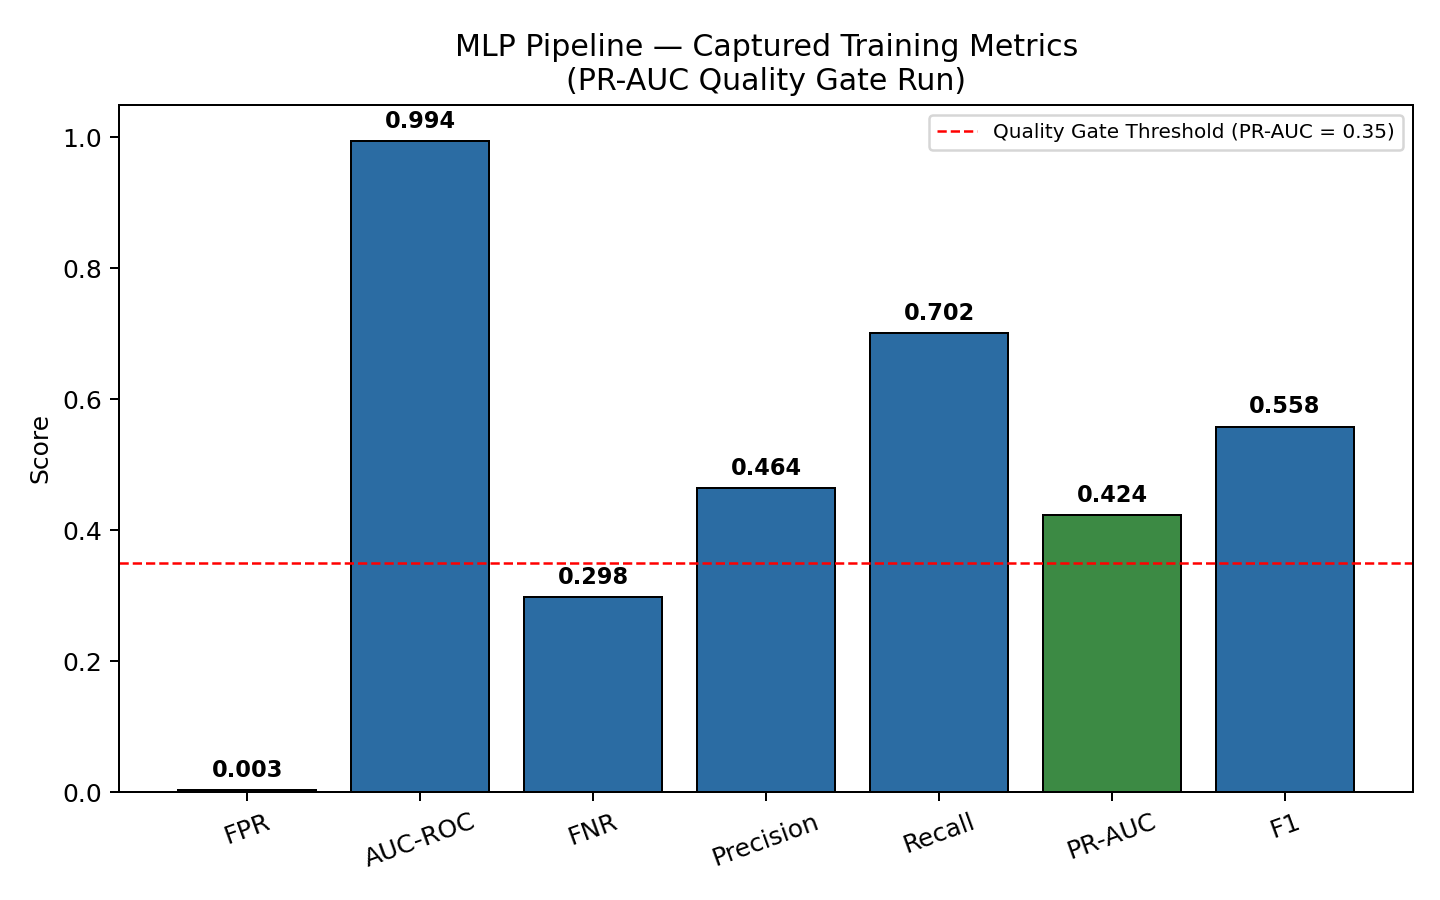

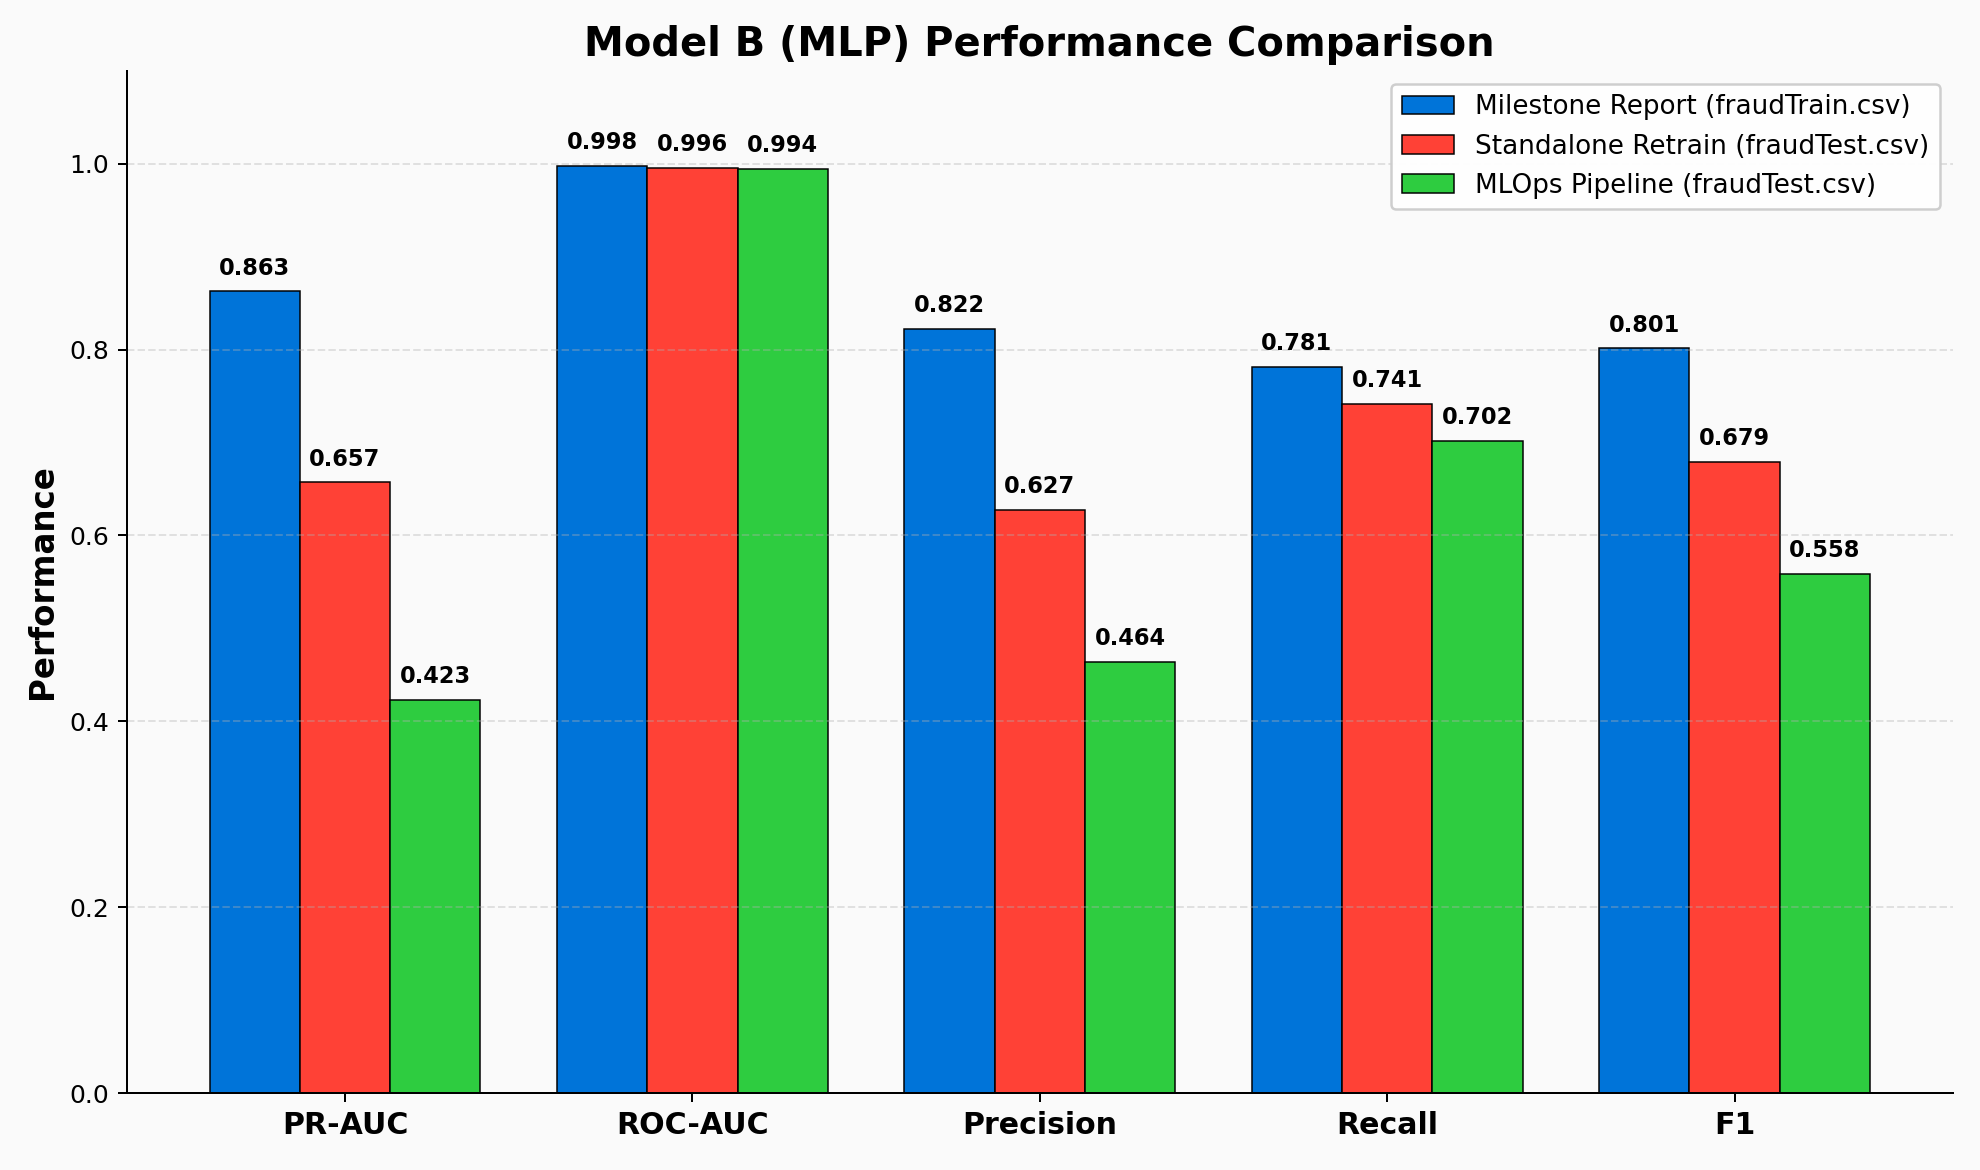
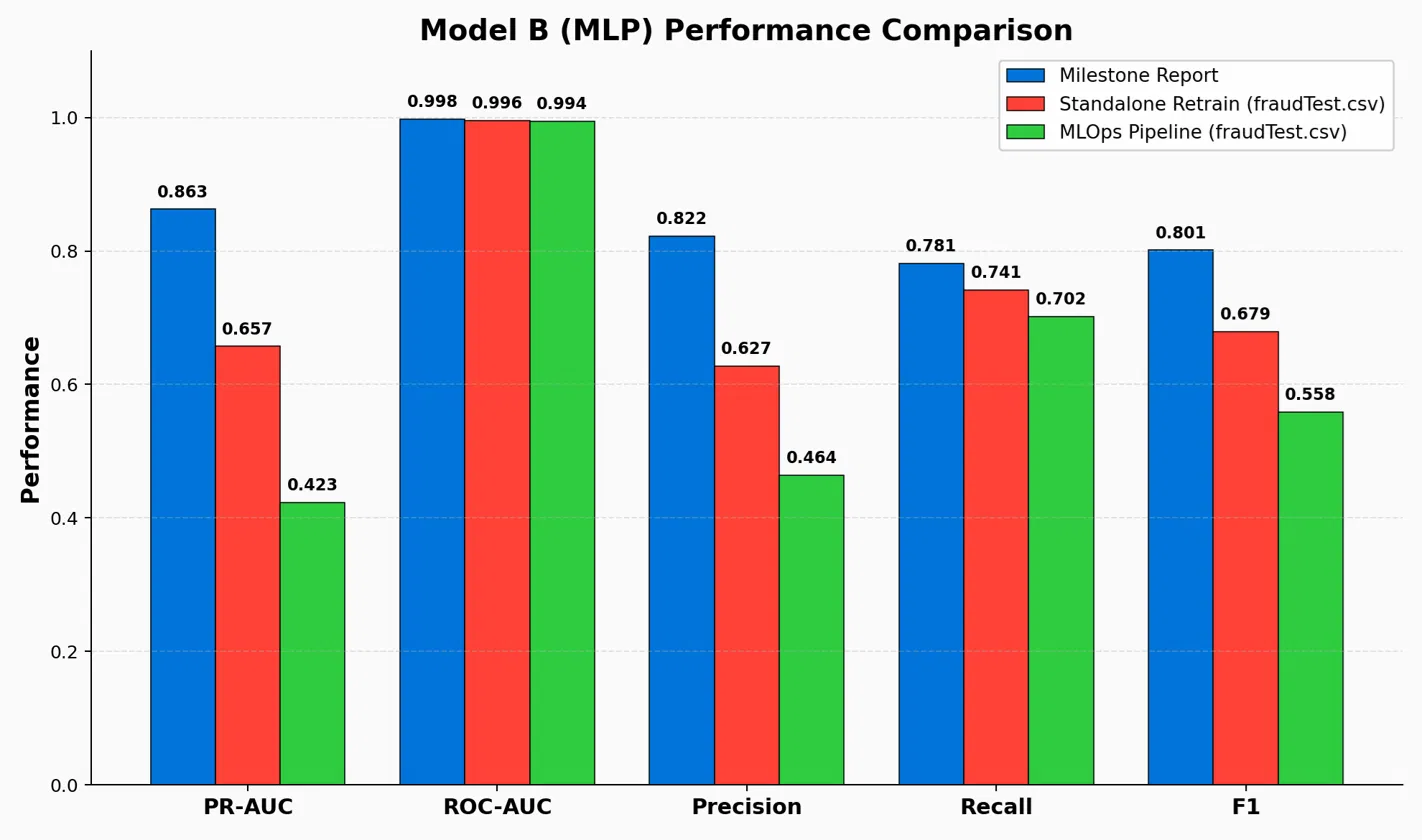

**FINDINGS ON MODEL B (MLP) PERFORMANCE COMPARISON**

**Observation:**
- ROC-AUC stayed consistently high across all three versions (0.994 - 0.998)
- PR-AUC and F1 dropped substantially at each version (PR-AUC: 0.863 → 0.657 → 0.423)

**Likely cause:**
- The pipeline's `preprocess.py`/`train.py` were reverse-engineered from the original notebook to make them pipeline-compatible
- This carries risk of subtle differences: train/test split, feature engineering details, or class-imbalance handling not fully replicated
- PR-AUC is highly sensitive to severely imbalanced dataset (0.58% fraud rate) whereas ROC-AUC is more forgiving and stays largely unaffected

**Conclusion:**
- This is not a flaw in either the model development or the MLOps pipeline - both were built correctly for their intended purpose.
- The gap is a genuine, valuable finding, showing where reproduction fidelity needs closer alignment
- Flagged as a concrete area for future investigation

### **STEP 09: DEPLOY SERVERLESS ENDPOINT**

In [22]:
# FETCH LATEST REGISTERED MODEL PACKAGE FROM MODEL REGISTRY AND SHOW APPROVAL STATUS

sm = boto3.client('sagemaker')

# Get the latest registered model package
pkgs = sm.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', SortOrder='Descending', MaxResults=1
)['ModelPackageSummaryList']

if not pkgs:
    print('No model packages found. Check the pipeline completed the Register step.')
else:
    pkg_arn = pkgs[0]['ModelPackageArn']
    print(f'Model package : {pkg_arn}')
    print(f'Status        : {pkgs[0]["ModelApprovalStatus"]}')

Model package : arn:aws:sagemaker:ap-southeast-1:044528205969:model-package/team04-credit-card-fraud-detection/45
Status        : PendingManualApproval


In [23]:
### CHECK MODEL REGISTRY STATUS
pkgs = sm.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', SortOrder='Descending', MaxResults=5
)['ModelPackageSummaryList']

print("=== Last 5 model packages ===")
for p in pkgs:
    print(p['ModelPackageArn'].split('/')[-1], '-', p['ModelApprovalStatus'])

=== Last 5 model packages ===
45 - PendingManualApproval
44 - Approved
43 - Approved
42 - Approved
41 - Approved


In [24]:
# APPROVE THE LATEST MODEL PACKAGE

sm.update_model_package(ModelPackageArn=pkg_arn, ModelApprovalStatus='Approved')
print(f'Approved: {pkg_arn}')


Approved: arn:aws:sagemaker:ap-southeast-1:044528205969:model-package/team04-credit-card-fraud-detection/45


In [25]:
### CHECK MODEL REGISTRY STATUS
pkgs = sm.list_model_packages(
    ModelPackageGroupName=MODEL_PACKAGE_GROUP,
    SortBy='CreationTime', SortOrder='Descending', MaxResults=5
)['ModelPackageSummaryList']

print("=== Last 5 model packages ===")
for p in pkgs:
    print(p['ModelPackageArn'].split('/')[-1], '-', p['ModelApprovalStatus'])

=== Last 5 model packages ===
45 - Approved
44 - Approved
43 - Approved
42 - Approved
41 - Approved


In [26]:
# DELETE ENDPOINT IF EXISTED
# UNCOMMENT IF NEEDED

import boto3
from botocore.exceptions import ClientError

REGION = boto3.Session().region_name
ENDPOINT_NAME = "iti113-team04-credit-card-fraud-detection-b"  # match your ENDPOINT_NAME

sm = boto3.client("sagemaker", region_name=REGION)

# 1. Delete the endpoint, if it exists
try:
    sm.describe_endpoint(EndpointName=ENDPOINT_NAME)
    print(f"Deleting endpoint: {ENDPOINT_NAME}")
    sm.delete_endpoint(EndpointName=ENDPOINT_NAME)
    waiter = sm.get_waiter("endpoint_deleted")
    waiter.wait(EndpointName=ENDPOINT_NAME)
    print("Endpoint deleted.")
except ClientError as e:
    if "Could not find endpoint" in str(e) or e.response["Error"]["Code"] == "ValidationException":
        print("No existing endpoint to delete.")
    else:
        raise

# 2. Delete the endpoint config, if it exists
try:
    sm.describe_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
    print(f"Deleting endpoint config: {ENDPOINT_NAME}")
    sm.delete_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
    print("Endpoint config deleted.")
except ClientError as e:
    if "Could not find endpoint configuration" in str(e) or e.response["Error"]["Code"] == "ValidationException":
        print("No existing endpoint config to delete.")
    else:
        raise

print("Cleanup done — safe to redeploy.")

No existing endpoint to delete.
No existing endpoint config to delete.
Cleanup done — safe to redeploy.


In [27]:
print(ENDPOINT_NAME)

iti113-team04-credit-card-fraud-detection-b


In [28]:
# DEPLOY APPROVED MODEL PACKAGE TO A SERVERLESS INFERENCE ENDPOINT

import sagemaker
from sagemaker import ModelPackage
from sagemaker.serverless import ServerlessInferenceConfig

deployable = ModelPackage(
    role=role,
    model_package_arn=pkg_arn,
    sagemaker_session=sagemaker.Session()
)

serverless_cfg = ServerlessInferenceConfig(memory_size_in_mb=2048, max_concurrency=5)

print(f'Deploying serverless endpoint: {ENDPOINT_NAME}')
print('This takes 3-5 minutes...')
predictor = deployable.deploy(
    serverless_inference_config=serverless_cfg,
    endpoint_name=ENDPOINT_NAME
)
print(f'Endpoint ready: {ENDPOINT_NAME}')
print('Cost: ~$0 idle. Charged per invocation only.')


/opt/conda/lib/python3.12/site-packages/sagemaker/model.py:347: SageMakerV2DeprecationWarning: ModelPackage is part of the SageMaker Python SDK v2, which is on path of deprecation. In v3, use `ModelBuilder` (`from sagemaker.serve import ModelBuilder`).
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.
  warn_v2_deprecation(
See https://github.com/aws/sagemaker-python-sdk/blob/master/migration.md for the migration guide. Set SAGEMAKER_SUPPRESS_V2_WARNING=1 to silence this warning.


INFO:sagemaker:Creating model with name: team04-credit-card-fraud-detection-2026-08-26-09-49-56-952


Deploying serverless endpoint: iti113-team04-credit-card-fraud-detection-b
This takes 3-5 minutes...


INFO:sagemaker:Creating endpoint-config with name iti113-team04-credit-card-fraud-detection-b


INFO:sagemaker:Creating endpoint with name iti113-team04-credit-card-fraud-detection-b


...

-

-

-

!

Endpoint ready: iti113-team04-credit-card-fraud-detection-b
Cost: ~$0 idle. Charged per invocation only.


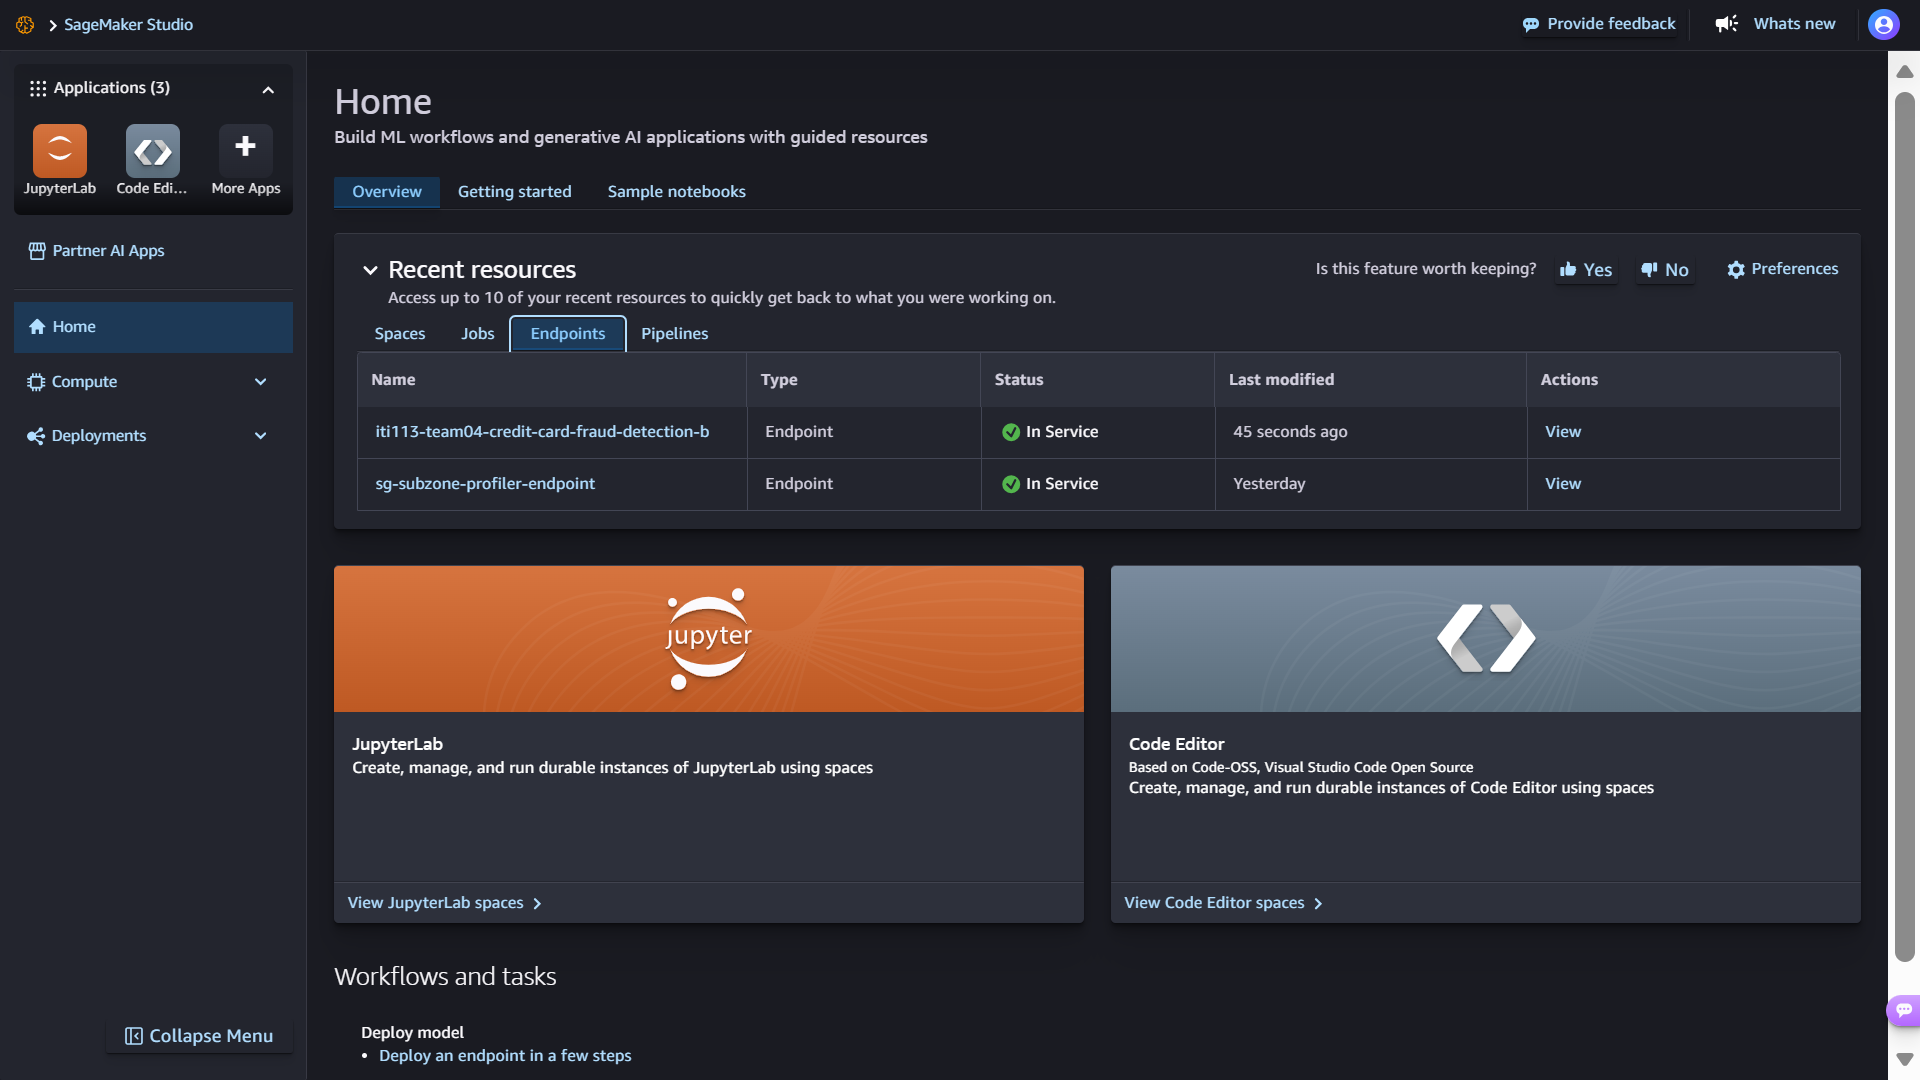

### **STEP 10: TEST THE LIVE ENDPOINT**

Starting test script...


Loaded 111144 rows from S3
=== Testing Endpoint: iti113-team04-credit-card-fraud-detection-b (20 Test Cases) ===



Test Case #01 | Actual: Legitimate | Predicted: Legitimate (0.0%) | ✓ CORRECT


Test Case #02 | Actual: Legitimate | Predicted: Legitimate (0.0%) | ✓ CORRECT


Test Case #03 | Actual: Legitimate | Predicted: Legitimate (0.0%) | ✓ CORRECT


...

Test Case #17 | Actual: Fraudulent | Predicted: Fraudulent (99.2%) | ✓ CORRECT


Test Case #18 | Actual: Fraudulent | Predicted: Fraudulent (99.9%) | ✓ CORRECT


Test Case #19 | Actual: Fraudulent | Predicted: Fraudulent (99.1%) | ✓ CORRECT


Test Case #20 | Actual: Fraudulent | Predicted: Legitimate (78.9%) | ✗ MISMATCH



Done.


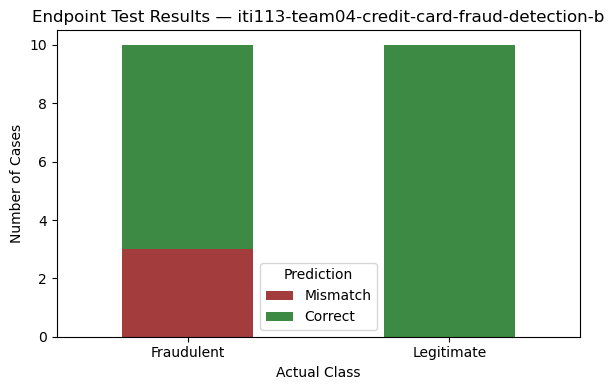


Accuracy: 17/20 (85.0%)


In [29]:
# LOAD SAMPLE FRAUD/LEGIT ROWS FROM FRAUDTEST.CSV
# TEST LIVE ENDPOINT PREDICTIONS ON 20 CASES (ACTUAL VS PREDICTED)
import json
import boto3
import pandas as pd
import matplotlib.pyplot as plt

print("Starting test script...")
s3_path = f"{PIPELINE_ROOT}/processed/test.csv"
df = pd.read_csv(s3_path)
print(f"Loaded {len(df)} rows from S3")

legit_samples = df[df['is_fraud'] == 0].sample(n=10, random_state=42)
fraud_samples = df[df['is_fraud'] == 1].sample(n=10, random_state=42)
test_samples = pd.concat([legit_samples, fraud_samples]).reset_index(drop=True)

# test.csv holds already-engineered fields (produced by preprocess.py), not the
# original raw Kaggle-schema fields -- this exercises inference.py's
# pre-engineered-fields path, not its raw-fields path.
RAW_FEATURE_COLUMNS = [
    "amt", "amt_log", "category", "city_pop", "age",
    "trans_hour_sin", "trans_hour_cos", "day_of_week", "is_weekend", "gender_binary",
    "txn_velocity_1h", "txn_velocity_6h", "txn_velocity_24h",
]

rt = boto3.client('sagemaker-runtime', region_name=region)
print(f"=== Testing Endpoint: {ENDPOINT_NAME} (20 Test Cases) ===\n")

results = []  # collect outcomes for the chart

for idx, row in test_samples.iterrows():
    actual_label = int(row['is_fraud'])
    actual_desc = "Fraudulent" if actual_label == 1 else "Legitimate"
    payload = row[RAW_FEATURE_COLUMNS].to_dict()
    try:
        resp = rt.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType='application/json',
            Body=json.dumps(payload, default=str)
        )
        result = json.loads(resp['Body'].read())[0]
        pred_label = result['is_fraud_predicted']
        prob = result['fraud_probability']
        pred_desc = "Fraudulent" if int(pred_label) == 1 else "Legitimate"
        correct = (pred_desc == actual_desc)
        match_status = "✓ CORRECT" if correct else "✗ MISMATCH"
        print(f"Test Case #{idx+1:02d} | Actual: {actual_desc:<10} | Predicted: {pred_desc:<10} ({prob:.1%}) | {match_status}", flush=True)
        results.append({"actual": actual_desc, "correct": correct})
    except Exception as e:
        print(f"Test Case #{idx+1:02d} | ERROR: {type(e).__name__}: {e}", flush=True)
        results.append({"actual": actual_desc, "correct": None})

print("\nDone.")

# ---- BAR CHART: correct vs mismatch, split by actual class ----
results_df = pd.DataFrame(results).dropna(subset=["correct"])
summary = results_df.groupby(["actual", "correct"]).size().unstack(fill_value=0)
summary = summary.rename(columns={True: "Correct", False: "Mismatch"})

ax = summary.plot(kind="bar", stacked=True, color={"Correct": "#3c8a44", "Mismatch": "#a33c3c"}, figsize=(6, 4))
ax.set_title(f"Endpoint Test Results — {ENDPOINT_NAME}")
ax.set_xlabel("Actual Class")
ax.set_ylabel("Number of Cases")
ax.legend(title="Prediction")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("endpoint_test_results_mlp.png", dpi=150)
plt.show()

total_correct = results_df["correct"].sum()
total_tested = len(results_df)
print(f"\nAccuracy: {total_correct}/{total_tested} ({total_correct/total_tested:.1%})")

**LIVE ENDPOINT TEST CONCLUSIONS:**
- 17/20 correct (85%)
- All 3 errors were false negatives

In [30]:
# INVENTORY CHECK: LIST TEAM'S ENDPOINTS AND PIPELINES BY NAME PREFIX
# MATCH TRAINING JOBS TO TEAM VIA JOB NAME PREFIX, PIPELINE EXECUTION ARN,
# OR PIPELINE HYPERPARAMETER TAGS

import boto3
import pandas as pd
from zoneinfo import ZoneInfo

sm_client = boto3.client("sagemaker")
PREFIX = "iti113-team04"
SGT = ZoneInfo("Asia/Singapore")

# 1. List Endpoints
endpoints_resp = sm_client.list_endpoints(NameContains=PREFIX, SortBy="CreationTime", SortOrder="Descending")
endpoints_data = [
    {
        "Endpoint Name": ep["EndpointName"],
        "Status": ep["EndpointStatus"],
        "Created At (SGT)": ep["CreationTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
    }
    for ep in endpoints_resp.get("Endpoints", [])
]

# 2. List Pipelines & collect execution ARNs
pipelines_resp = sm_client.list_pipelines(PipelineNamePrefix=PREFIX, SortBy="Name", SortOrder="Descending")
pipelines_data = []
team_pipelines = []
team_exec_arns = set()

for pipe in pipelines_resp.get("PipelineSummaries", []):
    p_name = pipe["PipelineName"]
    team_pipelines.append(p_name)
    pipelines_data.append({
        "Pipeline Name": p_name,
        "Display Name": pipe.get("PipelineDisplayName", "-"),
        "Last Modified (SGT)": pipe["LastModifiedTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
    })

    # Collect pipeline execution ARNs to match against training jobs
    try:
        execs = sm_client.list_pipeline_executions(PipelineName=p_name)
        for e in execs.get("PipelineExecutionSummaries", []):
            team_exec_arns.add(e["PipelineExecutionArn"])
    except Exception:
        pass

# 3. Identify Your Training Jobs (via tags, execution ARNs, and name prefixes)
recent_jobs = sm_client.list_training_jobs(SortBy="CreationTime", SortOrder="Descending", MaxResults=20)
my_training_jobs = []

for job in recent_jobs.get("TrainingJobSummaries", []):
    job_name = job["TrainingJobName"]
    detail = sm_client.describe_training_job(TrainingJobName=job_name)

    # Check job tags
    tags = sm_client.list_tags(ResourceArn=detail["TrainingJobArn"]).get("Tags", [])
    tag_dict = {t["Key"]: t["Value"] for t in tags}

    is_mine = False
    source = "Unknown"

    # Check 1: Job Name prefix
    if PREFIX in job_name:
        is_mine = True
        source = f"Job Name Prefix ({PREFIX})"

    # Check 2: Pipeline Execution ARN tag match
    elif "sagemaker:pipeline-execution-arn" in tag_dict:
        pipe_arn = tag_dict["sagemaker:pipeline-execution-arn"]
        if pipe_arn in team_exec_arns:
            is_mine = True
            source = f"Pipeline: {pipe_arn.split('/')[-3]}"

    # Check 3: Pipeline Hyperparameters match
    elif "sagemaker_pipeline_name" in detail.get("HyperParameters", {}):
        pipe_name = detail["HyperParameters"]["sagemaker_pipeline_name"].strip('"')
        if pipe_name in team_pipelines:
            is_mine = True
            source = f"Pipeline: {pipe_name}"

    if is_mine:
        my_training_jobs.append({
            "Training Job Name": job_name,
            "Source / Origin": source,
            "Status": job["TrainingJobStatus"],
            "Created At (SGT)": job["CreationTime"].astimezone(SGT).strftime("%Y-%m-%d %H:%M:%S")
        })

# Display Summary
print(f"=== YOUR ENDPOINTS (Prefix: '{PREFIX}') ===")
display(pd.DataFrame(endpoints_data) if endpoints_data else f"No endpoints found matching '{PREFIX}'.")

print(f"\n=== YOUR PIPELINES (Prefix: '{PREFIX}') ===")
display(pd.DataFrame(pipelines_data) if pipelines_data else f"No pipelines found matching '{PREFIX}'.")

print(f"\n=== YOUR TRAINING JOBS ===")
display(pd.DataFrame(my_training_jobs) if my_training_jobs else "No training jobs explicitly matched to your team.")

=== YOUR ENDPOINTS (Prefix: 'iti113-team04') ===


,Endpoint Name,Status,Created At (SGT)
0,iti113-team04-credit-card-fraud-detection-b,InService,2026-08-26 17:49:58



=== YOUR PIPELINES (Prefix: 'iti113-team04') ===


,Pipeline Name,Display Name,Last Modified (SGT)
0,iti113-team04-heart-disease,iti113-team04-heart-disease,2026-08-01 18:09:05
1,iti113-team04-credit-card-fraud-detection,iti113-team04-credit-card-fraud-detection,2026-08-26 17:46:12



=== YOUR TRAINING JOBS ===


,Training Job Name,Source / Origin,Status,Created At (SGT)
0,pipelines-3lgs99g6ukv7-Team04-RegisterModel-z1...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 17:43:39
1,pipelines-3lgs99g6ukv7-Team04-TrainModel-mxI9w...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 17:35:34
2,pipelines-8jojxstkvo3b-Team04-TrainModel-bgNbx...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 16:11:50
3,pipelines-tzhqrdo44lsz-Team04-TrainModel-mf07w...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 15:57:02
4,pipelines-vktoksiazp2y-Team04-TrainModel-oMXVA...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 15:31:43
5,pipelines-ts9baru0kfq3-Team04-RegisterModel-iS...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 14:50:35
6,pipelines-ts9baru0kfq3-Team04-TrainModel-DJMh1...,Pipeline: iti113-team04-credit-card-fraud-dete...,Completed,2026-08-26 14:42:36


### **STEP 11: SIMPLE SERVERLESS GRADIO USER INTERFACE**

In [31]:
!pip install -q "starlette<1" "fastapi<1" --upgrade
!pip install -q gradio

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
autogluon-multimodal 1.5.0 requires fsspec[http]<=2025.3, but you have fsspec 2026.6.0 which is incompatible.
datasets 2.2.1 requires huggingface-hub<1.0.0,>=0.1.0, but you have huggingface-hub 1.28.0 which is incompatible.
sagemaker-mlops 1.12.0 requires sagemaker-core>=2.12.0, but you have sagemaker-core 1.0.78 which is incompatible.
transformers 4.57.6 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.28.0 which is incompatible.


In [33]:
import json
import boto3
import numpy as np
import pandas as pd
import gradio as gr

runtime = boto3.client("sagemaker-runtime", region_name=region)

def predict_credit_card_fraud(
    trans_date_trans_time, dob, amt, category, city_pop, gender,
    velocity_1h, velocity_6h, velocity_24h
):
    try:
        dt = pd.to_datetime(trans_date_trans_time, errors='coerce')
        birth = pd.to_datetime(dob, errors='coerce')

        age = dt.year - birth.year
        if (dt.month, dt.day) < (birth.month, birth.day):
            age -= 1

        amt_val = float(amt)
        amt_log = np.log1p(max(amt_val, 0))

        hour = dt.hour
        trans_hour_sin = np.sin(2 * np.pi * hour / 24)
        trans_hour_cos = np.cos(2 * np.pi * hour / 24)

        day_of_week = dt.dayofweek
        is_weekend = int(day_of_week >= 5)

        gender_binary = 1 if str(gender).upper() == "M" else 0

        input_dict = {
            "amt": amt_val,
            "amt_log": float(amt_log),
            "category": str(category),
            "city_pop": int(city_pop),
            "age": int(age),
            "trans_hour_sin": float(trans_hour_sin),
            "trans_hour_cos": float(trans_hour_cos),
            "day_of_week": int(day_of_week),
            "is_weekend": is_weekend,
            "gender_binary": gender_binary,
            "txn_velocity_1h": float(velocity_1h),
            "txn_velocity_6h": float(velocity_6h),
            "txn_velocity_24h": float(velocity_24h),
        }

        response = runtime.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType="application/json",
            Body=json.dumps(input_dict),
        )
        result = json.loads(response["Body"].read())[0]

        is_fraud = result.get("is_fraud_predicted", "Unknown")
        probability = result.get("fraud_probability", None)
        threshold = result.get("operating_threshold", None)

        prediction_label = "Fraudulent" if int(is_fraud) == 1 else "Legitimate"
        probability_text = f"{probability:.1%}" if probability is not None else "Not returned"
        threshold_text = f"{threshold:.2f}" if threshold is not None else "Not returned"

        return (
            f"Endpoint: {ENDPOINT_NAME}\n"
            f"Prediction: {prediction_label}\n"
            f"Fraud Probability: {probability_text}\n"
            f"Operating Threshold: {threshold_text}\n\n"
            f"Engineered Input Sent:\n{json.dumps(input_dict, indent=2)}"
        )

    except Exception as e:
        return f"Error invoking endpoint.\nEndpoint: {ENDPOINT_NAME}\nError: {str(e)}"

In [34]:
import gradio as gr

def parse_and_populate(raw_text):
    """Parses 'field: value' lines pasted by the user and fills all inputs."""
    parsed = {}
    for line in raw_text.strip().splitlines():
        if ":" in line:
            key, _, value = line.partition(":")
            parsed[key.strip()] = value.strip()

    def safe_float(key, default=0.0):
        try:
            return float(parsed.get(key, default))
        except (ValueError, TypeError):
            return default

    def safe_int(key, default=0):
        try:
            return int(float(parsed.get(key, default)))
        except (ValueError, TypeError):
            return default

    gender_val = parsed.get("gender", "M").upper()
    gender_val = gender_val if gender_val in ("M", "F") else "M"

    return (
        parsed.get("trans_date_trans_time", ""),
        parsed.get("dob", ""),
        safe_float("amt"),
        parsed.get("category", ""),
        safe_int("city_pop"),
        gender_val,
        safe_float("txn_velocity_1h"),
        safe_float("txn_velocity_6h"),
        safe_float("txn_velocity_24h"),
    )

custom_css = """
.gradio-container { border: 2px solid #000; border-radius: 8px; padding: 16px; }
input, textarea, select { border: 1px solid #000 !important; color: #000 !important; }
label { color: #000 !important; }
"""

theme = gr.themes.Soft(primary_hue="blue", secondary_hue="orange", neutral_hue="slate")

with gr.Blocks(title="ITI113 Credit Card Fraud Detection Demo", theme=theme, css=custom_css) as demo:
    gr.Markdown(
        f"""
        # ITI113 Credit Card Fraud Detection Demo by Team 04
        **Endpoint:** `{ENDPOINT_NAME}` &nbsp;|&nbsp; **Region:** `{region}`
        **Model:** Model B (MLP) — raw fields are engineered client-side before calling the endpoint.
        """
    )

    with gr.Accordion("Paste a Sample to Auto-Fill", open=False):
        paste_box = gr.Textbox(
            label="Paste 'field: value' lines here",
            placeholder="trans_date_trans_time: 2020-07-30 00:52:25\ndob: 1988-04-12\namt: 980.50\ncategory: shopping_net\ncity_pop: 2500\ngender: M\ntxn_velocity_1h: 0\ntxn_velocity_6h: 1\ntxn_velocity_24h: 3",
            lines=7,
        )
        populate_button = gr.Button("Populate Fields", size="sm")

    with gr.Row():
        trans_date_trans_time = gr.Textbox(label="Transaction Date/Time", value="2026-08-19 14:30:00")
        dob = gr.Textbox(label="DOB (YYYY-MM-DD)", value="1988-04-12")
        category = gr.Textbox(label="Category", value="shopping_net")
        gender = gr.Dropdown(label="Gender", choices=["M", "F"], value="M")

    with gr.Row():
        amt = gr.Number(label="Amount ($)", value=980.50)
        city_pop = gr.Number(label="City Population", value=2500)

    with gr.Row():
        velocity_1h = gr.Number(label="Transactions in past 1h (this card)", value=0)
        velocity_6h = gr.Number(label="Transactions in past 6h (this card)", value=1)
        velocity_24h = gr.Number(label="Transactions in past 24h (this card)", value=3)

    with gr.Row():
        predict_button = gr.Button("Detect Fraud", variant="primary", scale=2)
        clear_button = gr.ClearButton(
            components=[trans_date_trans_time, dob, amt, category, city_pop, gender,
                        velocity_1h, velocity_6h, velocity_24h, paste_box],
            value="Clear All",
            scale=1,
        )

    output = gr.Textbox(label="Prediction Result", lines=8)
    clear_button.add(output)

    populate_button.click(
        fn=parse_and_populate,
        inputs=[paste_box],
        outputs=[trans_date_trans_time, dob, amt, category, city_pop, gender,
                 velocity_1h, velocity_6h, velocity_24h],
    )

    predict_button.click(
        fn=predict_credit_card_fraud,
        inputs=[trans_date_trans_time, dob, amt, category, city_pop, gender,
                velocity_1h, velocity_6h, velocity_24h],
        outputs=output
    )

demo.launch(inline=True, share=True, debug=True)

/tmp/ipykernel_888/4294527799.py:46: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="ITI113 Credit Card Fraud Detection Demo", theme=theme, css=custom_css) as demo:


INFO:httpx:HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"


...

INFO:httpx:HTTP Request: GET https://api.gradio.app/v3/tunnel-request "HTTP/1.1 200 OK"


* Running on public URL: https://6d0915162fadf7ceab.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


INFO:httpx:HTTP Request: HEAD https://6d0915162fadf7ceab.gradio.live "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6d0915162fadf7ceab.gradio.live


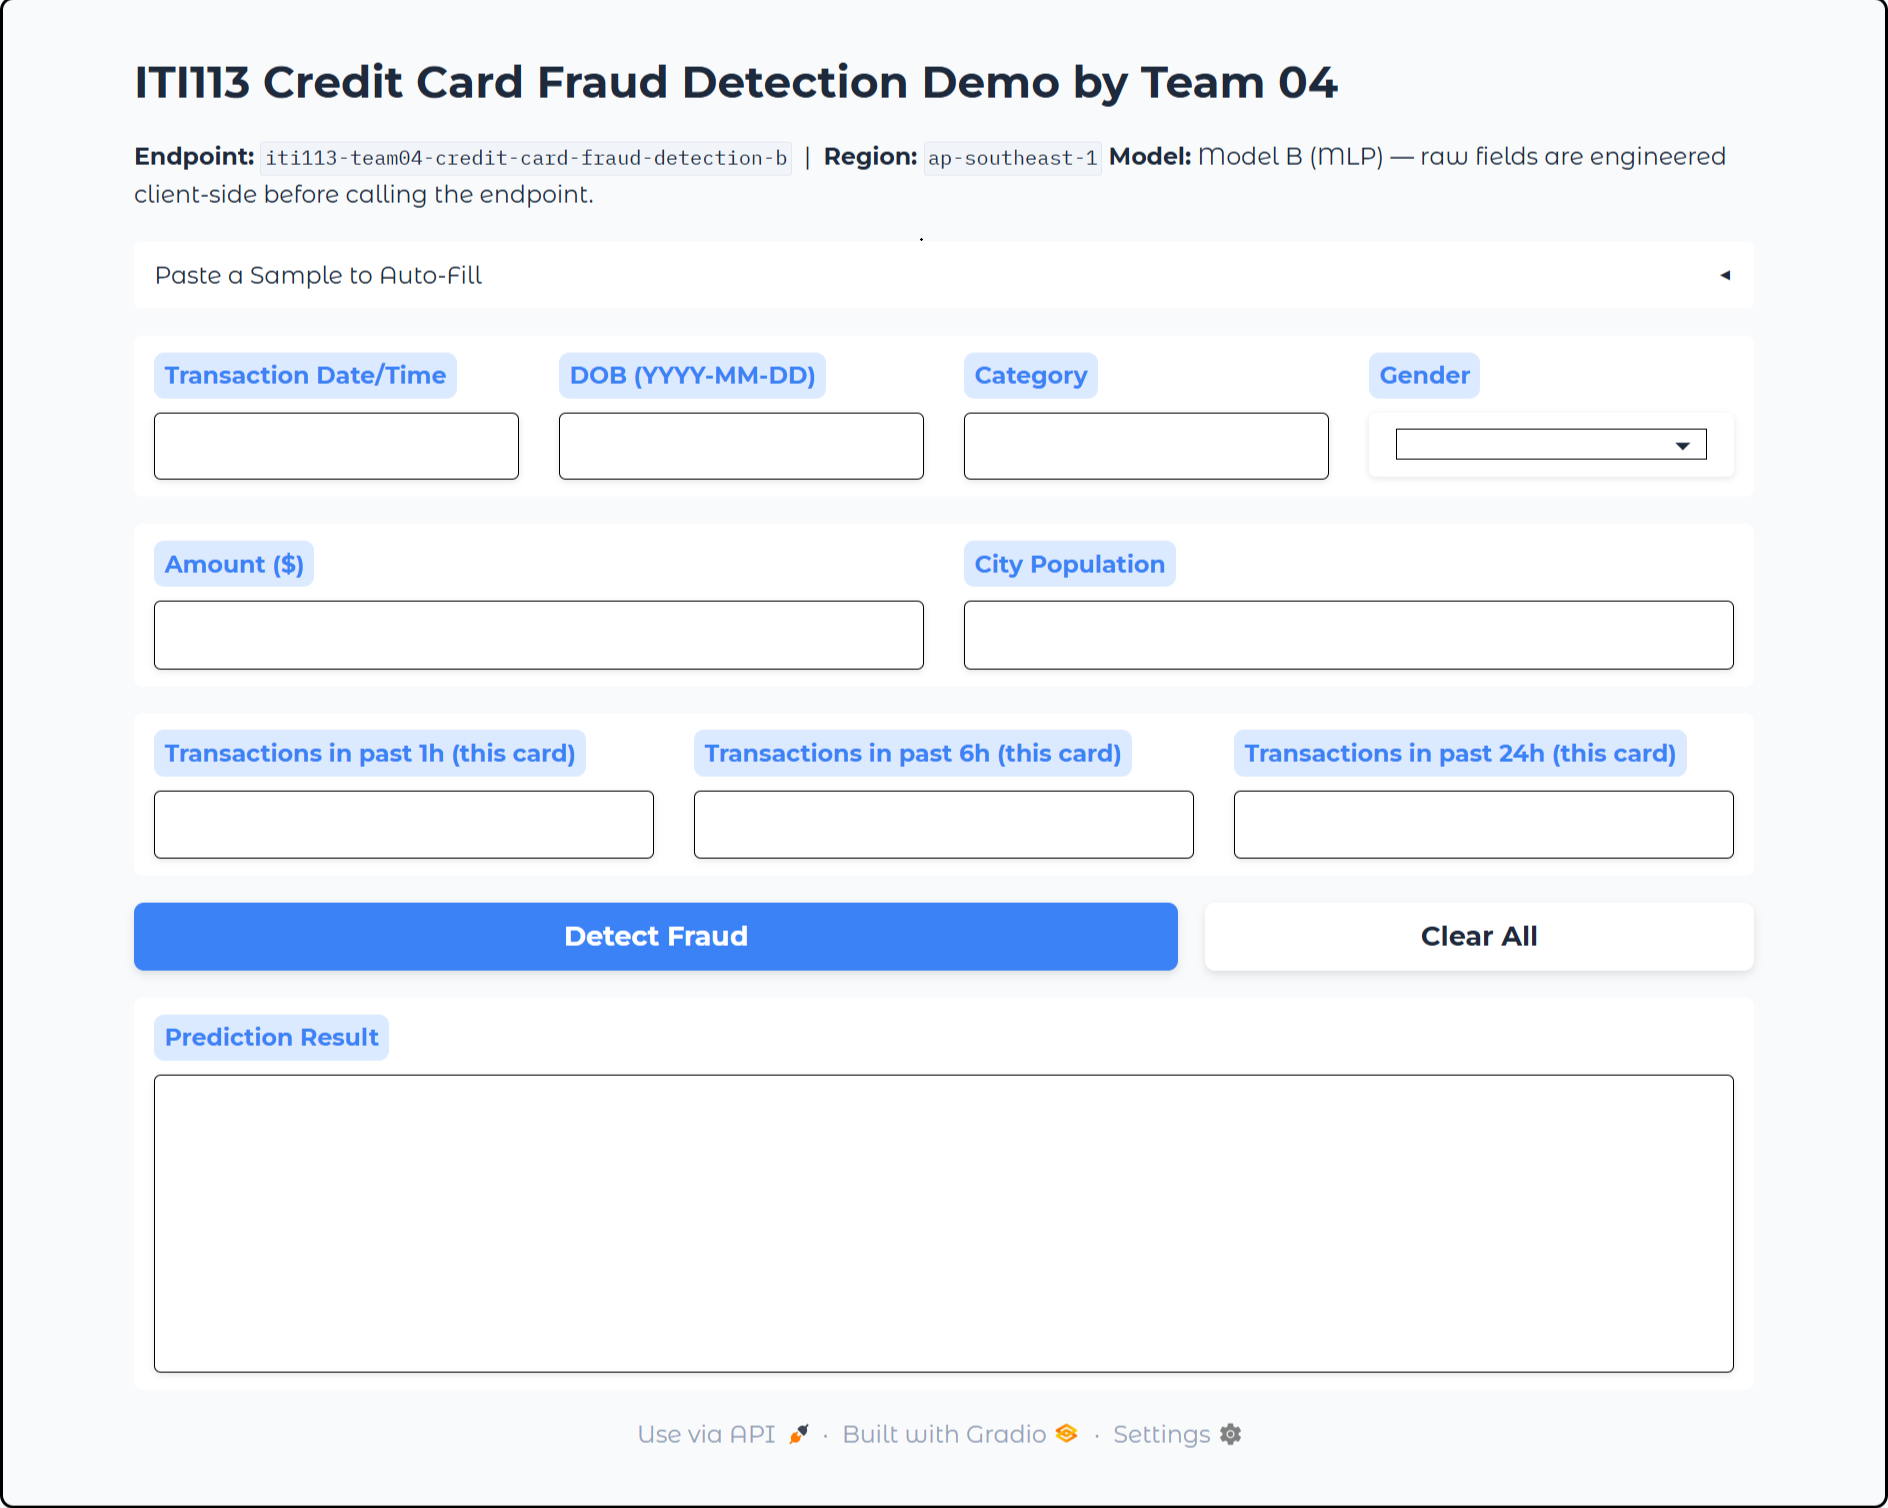

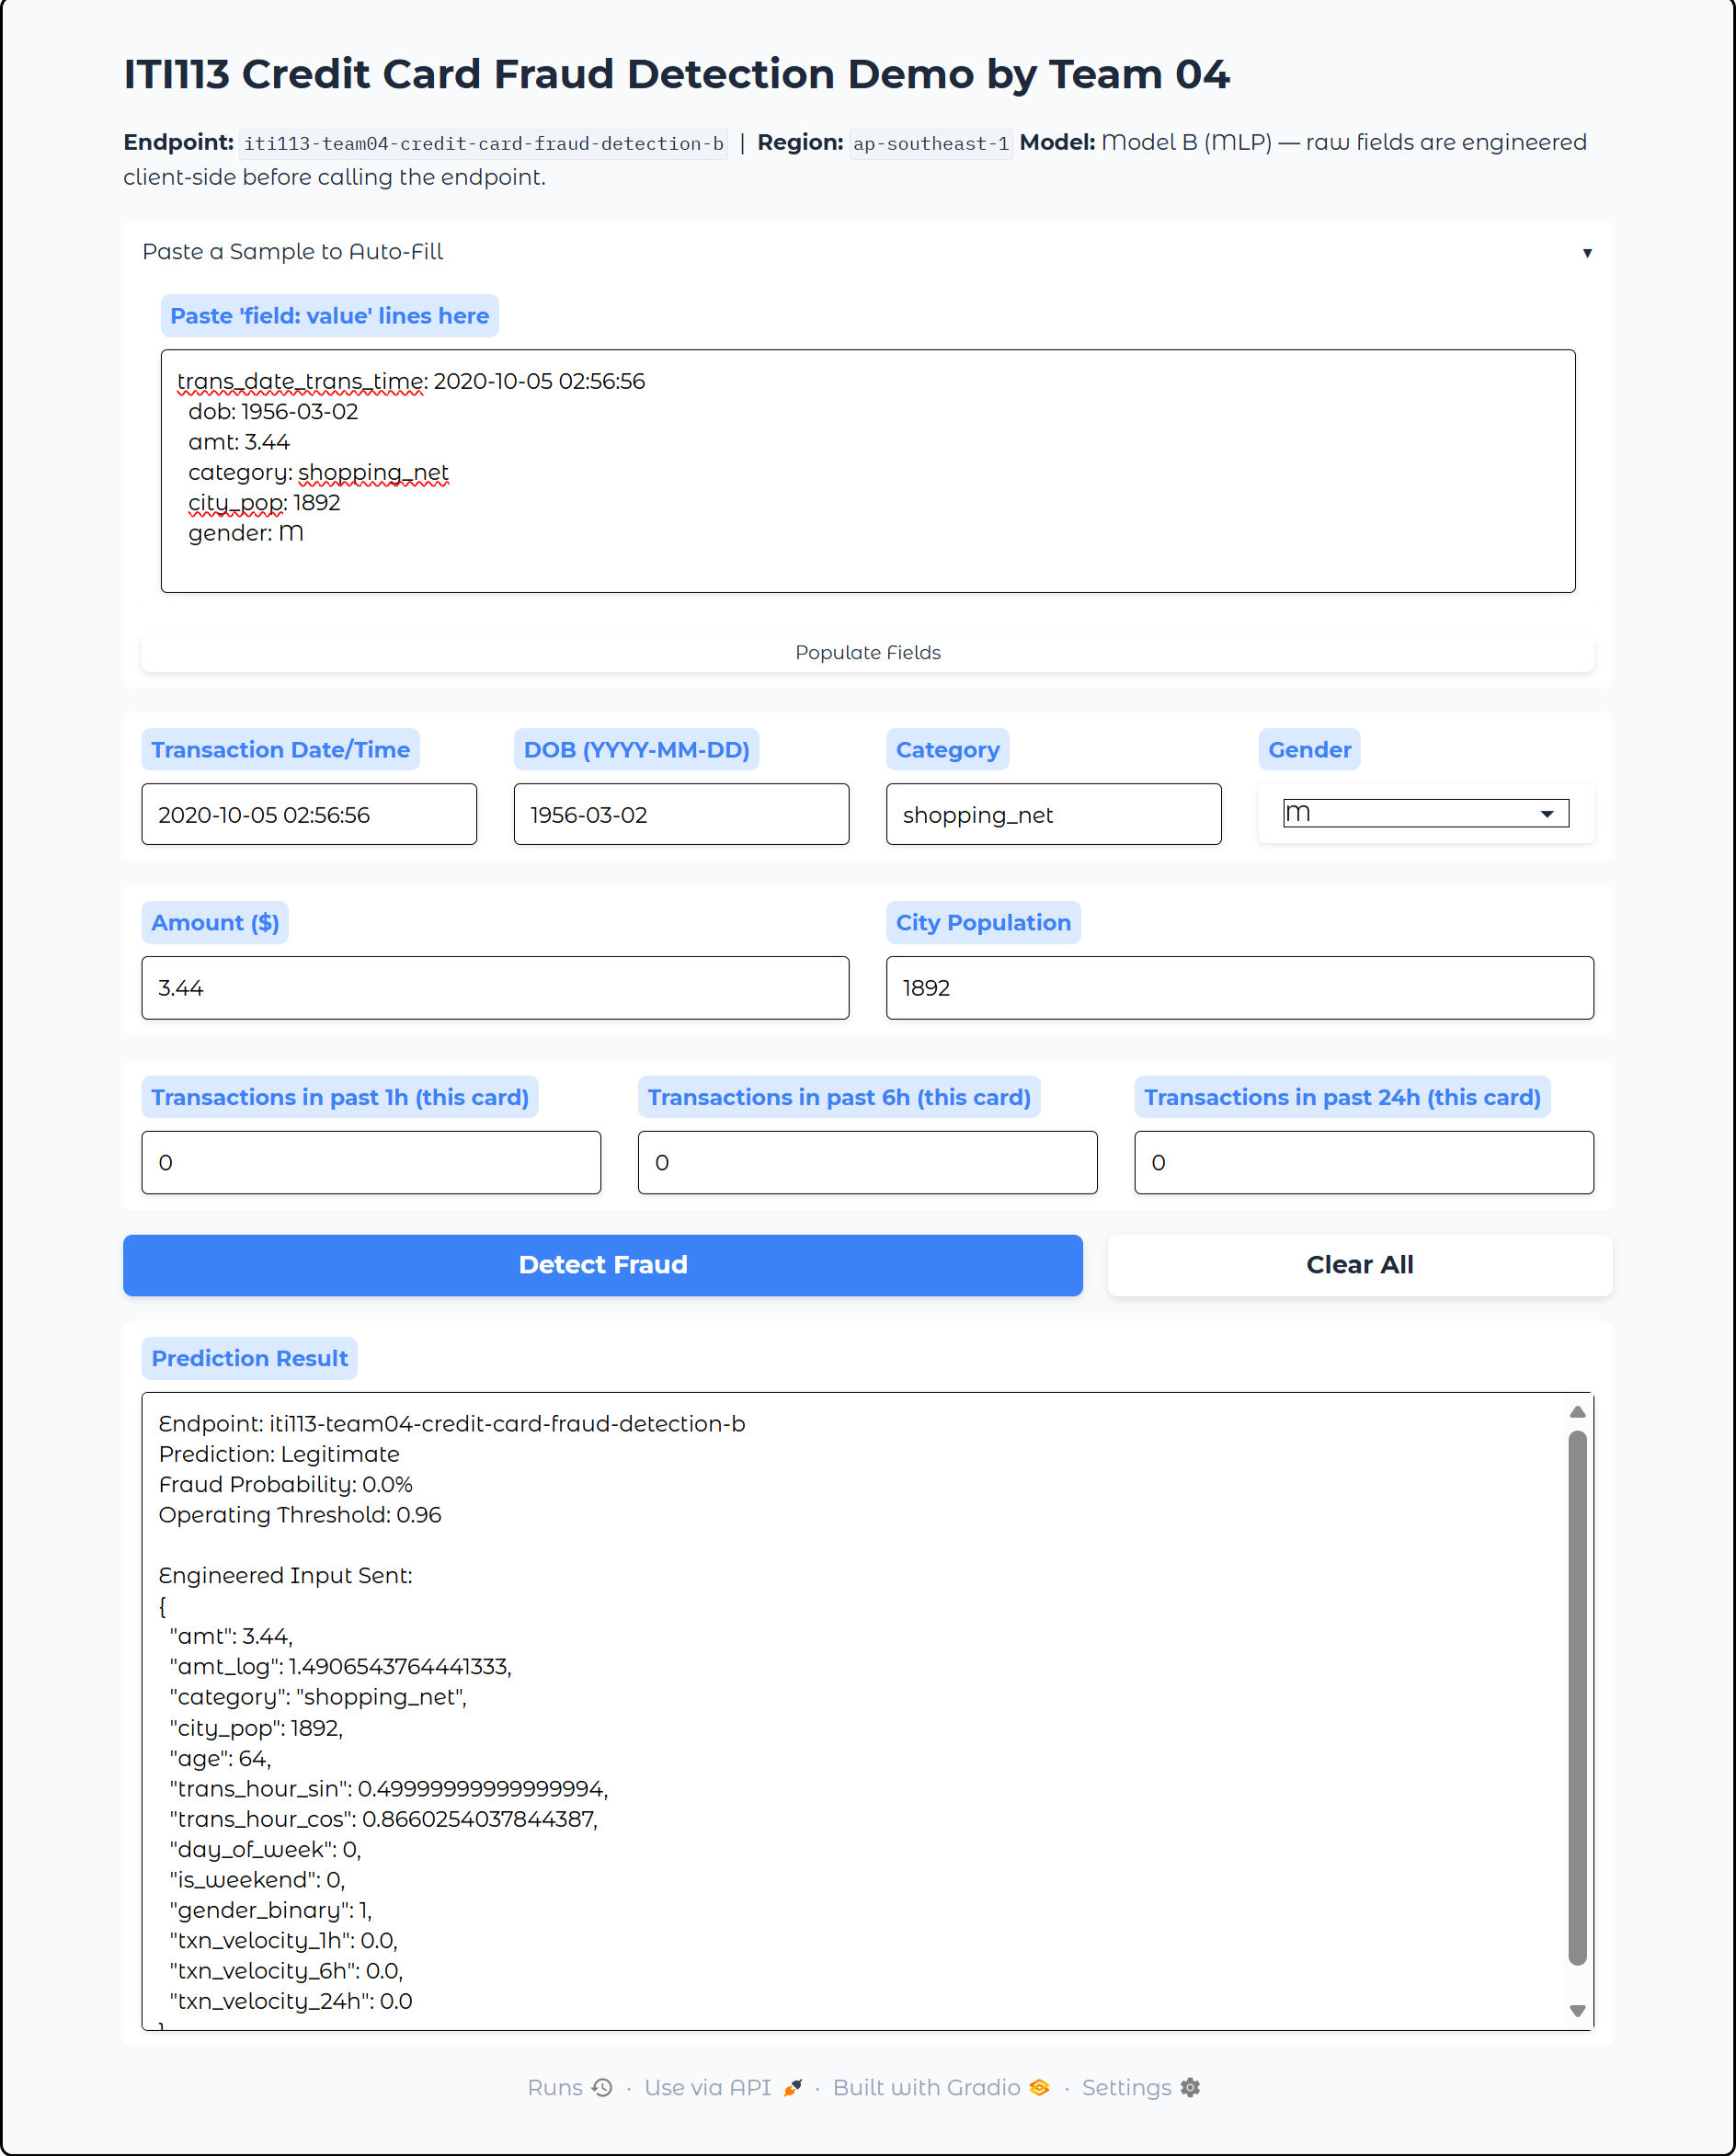

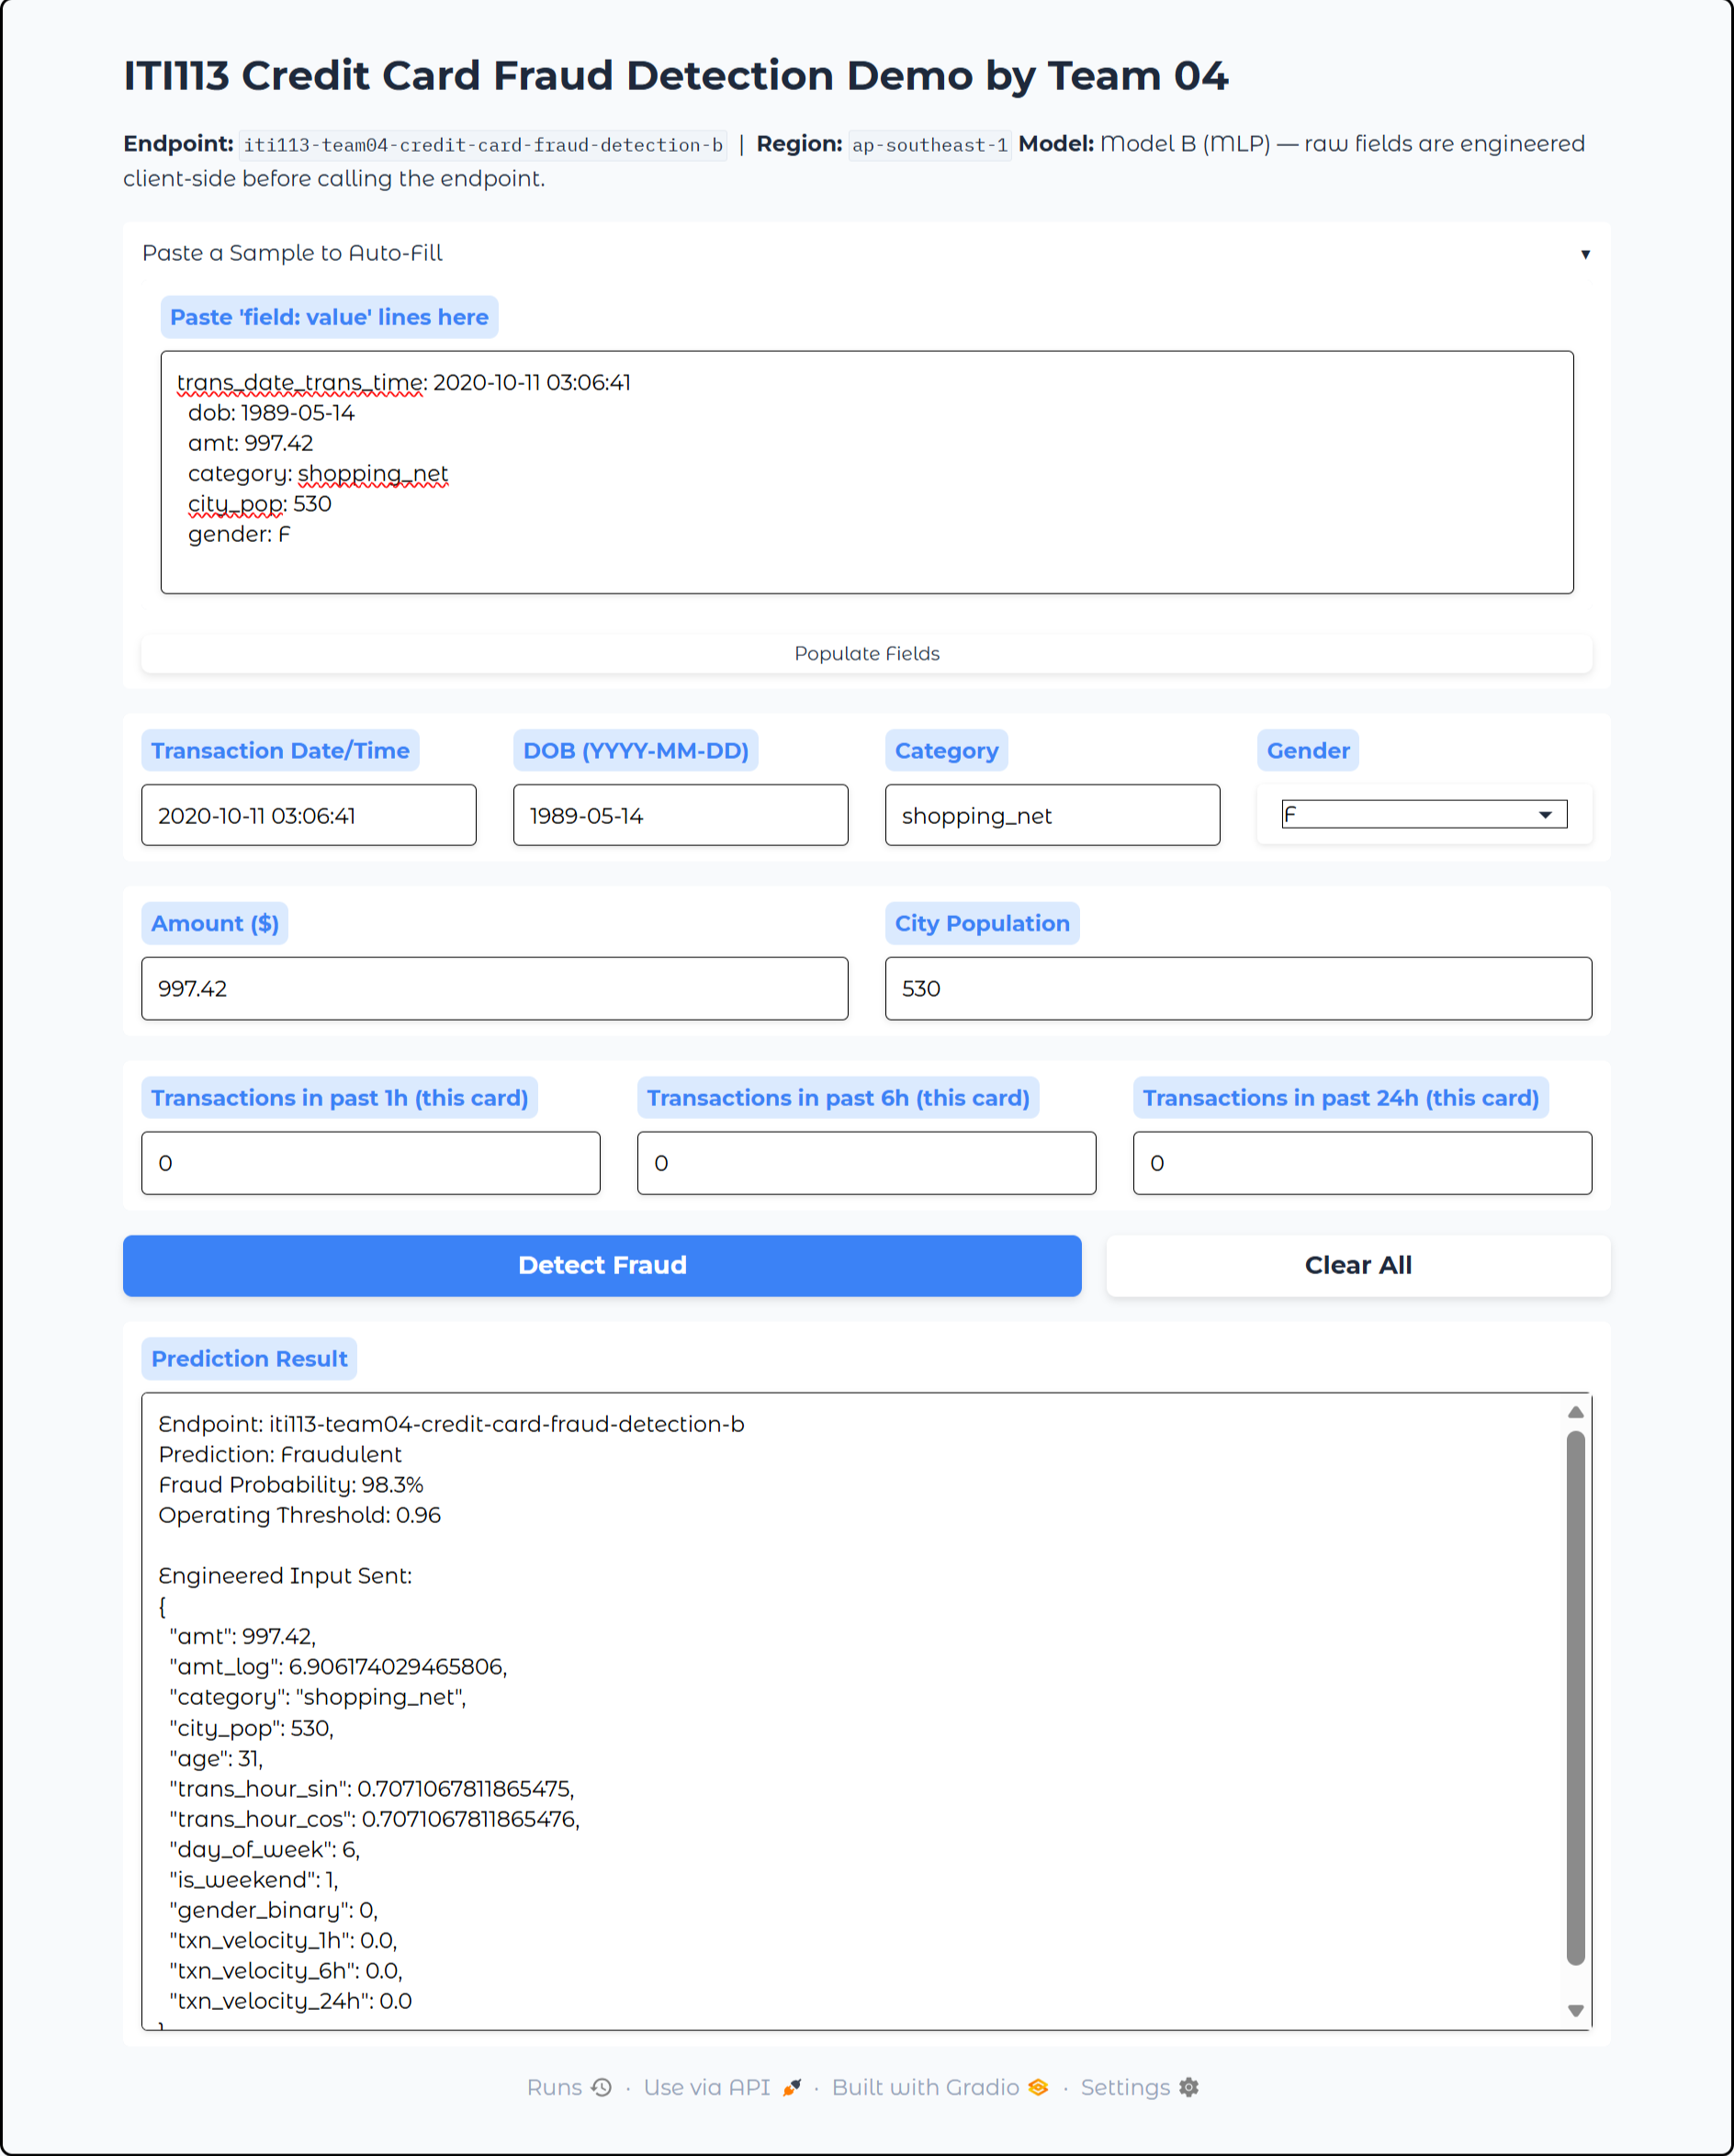

**GRADIO TEST SAMPLES AND RESULTS:**

In [ ]:
"""
--- SAMPLE #01 (Actual: Legitimate) ---
    trans_date_trans_time: 2020-10-05 02:56:56
    dob: 1956-03-02
    amt: 3.44
    category: shopping_net
    city_pop: 1892
    gender: M
  
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 0.0%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 3.44,
      "amt_log": 1.4906543764441333,
      "category": "shopping_net",
      "city_pop": 1892,
      "age": 64,
      "trans_hour_sin": 0.49999999999999994,
      "trans_hour_cos": 0.8660254037844387,
      "day_of_week": 0,
      "is_weekend": 0,
      "gender_binary": 1,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #02 (Actual: Legitimate) ---
    trans_date_trans_time: 2020-12-17 08:27:16
    dob: 1959-10-07
    amt: 8.49
    category: shopping_pos
    city_pop: 5791
    gender: M

    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 0.0%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 8.49,
      "amt_log": 2.2502386126218363,
      "category": "shopping_pos",
      "city_pop": 5791,
      "age": 61,
      "trans_hour_sin": 0.8660254037844387,
      "trans_hour_cos": -0.4999999999999998,
      "day_of_week": 3,
      "is_weekend": 0,
      "gender_binary": 1,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #03 (Actual: Legitimate) ---
    trans_date_trans_time: 2020-12-21 20:32:35
    dob: 1976-05-24
    amt: 14.16
    category: personal_care
    city_pop: 513
    gender: F

    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 0.8%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 14.16,
      "amt_log": 2.7186603802142257,
      "category": "personal_care",
      "city_pop": 513,
      "age": 44,
      "trans_hour_sin": -0.8660254037844386,
      "trans_hour_cos": 0.5000000000000001,
      "day_of_week": 0,
      "is_weekend": 0,
      "gender_binary": 0,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #04 (Actual: Legitimate) ---
    trans_date_trans_time: 2020-07-22 03:16:32
    dob: 1997-07-05
    amt: 43.83
    category: gas_transport
    city_pop: 2408
    gender: F
  
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 0.0%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 43.83,
      "amt_log": 3.802877558167348,
      "category": "gas_transport",
      "city_pop": 2408,
      "age": 23,
      "trans_hour_sin": 0.7071067811865475,
      "trans_hour_cos": 0.7071067811865476,
      "day_of_week": 2,
      "is_weekend": 0,
      "gender_binary": 0,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #05 (Actual: Legitimate) ---
    trans_date_trans_time: 2020-08-09 12:48:45
    dob: 1981-10-24
    amt: 17.44
    category: kids_pets
    city_pop: 1312922
    gender: F
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 0.0%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 17.44,
      "amt_log": 2.9145222181284476,
      "category": "kids_pets",
      "city_pop": 1312922,
      "age": 38,
      "trans_hour_sin": 1.2246467991473532e-16,
      "trans_hour_cos": -1.0,
      "day_of_week": 6,
      "is_weekend": 1,
      "gender_binary": 0,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }
   
--- SAMPLE #06 (Actual: Fraudulent) ---
    trans_date_trans_time: 2020-10-11 03:06:41
    dob: 1989-05-14
    amt: 997.42
    category: shopping_net
    city_pop: 530
    gender: F
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Fraudulent
    Fraud Probability: 98.3%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 997.42,
      "amt_log": 6.906174029465806,
      "category": "shopping_net",
      "city_pop": 530,
      "age": 31,
      "trans_hour_sin": 0.7071067811865475,
      "trans_hour_cos": 0.7071067811865476,
      "day_of_week": 6,
      "is_weekend": 1,
      "gender_binary": 0,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }
 
--- SAMPLE #07 (Actual: Fraudulent) ---
    trans_date_trans_time: 2020-06-21 23:59:05
    dob: 1958-09-10
    amt: 955.16
    category: shopping_net
    city_pop: 1306
    gender: M
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Fraudulent
    Fraud Probability: 98.9%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 955.16,
      "amt_log": 6.8629252630643425,
      "category": "shopping_net",
      "city_pop": 1306,
      "age": 61,
      "trans_hour_sin": -0.25881904510252157,
      "trans_hour_cos": 0.9659258262890681,
      "day_of_week": 6,
      "is_weekend": 1,
      "gender_binary": 1,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #08 (Actual: Fraudulent) ---
    trans_date_trans_time: 2020-12-08 03:01:53
    dob: 1999-03-05
    amt: 315.25
    category: grocery_pos
    city_pop: 2870
    gender: M
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Fraudulent
    Fraud Probability: 97.3%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 315.25,
      "amt_log": 5.75653304004173,
      "category": "grocery_pos",
      "city_pop": 2870,
      "age": 21,
      "trans_hour_sin": 0.7071067811865475,
      "trans_hour_cos": 0.7071067811865476,
      "day_of_week": 1,
      "is_weekend": 0,
      "gender_binary": 1,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }

--- SAMPLE #09 (Actual: Fraudulent) ---
    trans_date_trans_time: 2020-12-04 21:50:46
    dob: 1982-07-30
    amt: 959.59
    category: shopping_pos
    city_pop: 172817
    gender: M
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Fraudulent
    Fraud Probability: 97.2%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 959.59,
      "amt_log": 6.867547679016221,
      "category": "shopping_pos",
      "city_pop": 172817,
      "age": 38,
      "trans_hour_sin": -0.7071067811865477,
      "trans_hour_cos": 0.7071067811865474,
      "day_of_week": 4,
      "is_weekend": 0,
      "gender_binary": 1,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }
        
--- SAMPLE #10 (Actual: Fraudulent) ---
    trans_date_trans_time: 2020-10-05 22:45:28
    dob: 1960-01-13
    amt: 858.76
    category: shopping_pos
    city_pop: 478
    gender: F
        
    OUTPUT:
    Endpoint: iti113-team04-credit-card-fraud-detection-b
    Prediction: Legitimate
    Fraud Probability: 95.0%
    Operating Threshold: 0.96
    Engineered Input Sent:
    {
      "amt": 858.76,
      "amt_log": 6.756653280532897,
      "category": "shopping_pos",
      "city_pop": 478,
      "age": 60,
      "trans_hour_sin": -0.5000000000000004,
      "trans_hour_cos": 0.8660254037844384,
      "day_of_week": 0,
      "is_weekend": 0,
      "gender_binary": 0,
      "txn_velocity_1h": 0.0,
      "txn_velocity_6h": 0.0,
      "txn_velocity_24h": 0.0
    }
"""

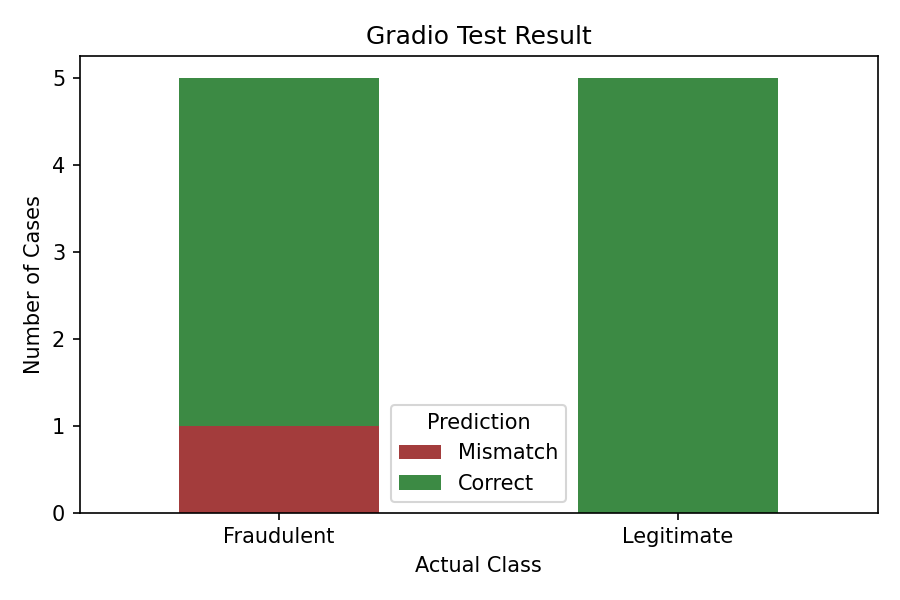
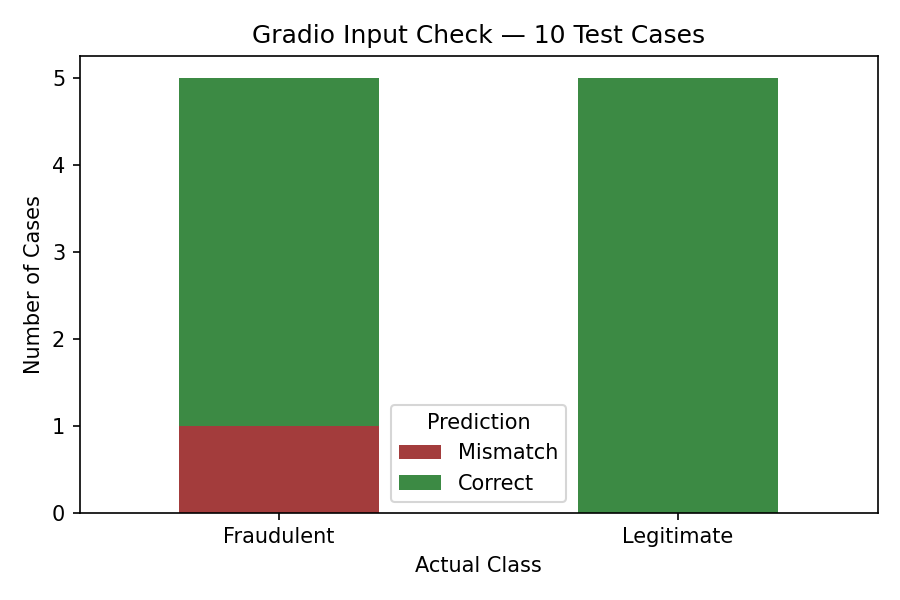

**GRADIO TEST CONCLUSIONS:**
- Gradio transforms raw inputs into model's required format correctly
- 9 of 10 predictions correct
- No interface error

In [36]:
# CLOSE GRADIO USER INTERFACE

demo.close()

# If [*], Kernel > Interrupt Kernel

Closing server running on port: 7860


### **STEP 12: PRINT NOTEBOOK 03 SUMMARY**

In [6]:
print('=' * 55)
print('NOTEBOOK 03 COMPLETE')
print('=' * 55)
print(f'Pipeline : {PIPELINE_NAME}')
print(f'MLflow   : {MLFLOW_EXPERIMENT_NAME} on SageMaker MLflow App')
print(f'MLflow App ARN : {MLFLOW_APP_ARN}')
print(f'SageMaker Registry : {MODEL_PACKAGE_GROUP}')
print(f'Endpoint : {ENDPOINT_NAME} (Serverless)')
print()

NOTEBOOK 03 COMPLETE
Pipeline : iti113-team04-credit-card-fraud-detection
MLflow   : ITI113/team04/Experiment-01 on SageMaker MLflow App
MLflow App ARN : arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
SageMaker Registry : team04-credit-card-fraud-detection
Endpoint : iti113-team04-credit-card-fraud-detection-b (Serverless)



### **STEP 13: DELETE ENDPOINT WHEN NO LONGER NEEDED**

In [35]:
# To delete endpoint when no longer needed, uncomment the lines below:

# TEK | 12 AUG 2026
session = boto3.Session()
REGION = session.region_name

ENDPOINT_NAME = "iti113-team04-credit-card-fraud-detection-b"

sm_cleanup = boto3.client('sagemaker', region_name=REGION)

sm_cleanup.delete_endpoint(EndpointName=ENDPOINT_NAME)
print(f'Endpoint deleted: {ENDPOINT_NAME}')

# TEK | 12 AUG 2026
sm_cleanup.delete_endpoint_config(EndpointConfigName=ENDPOINT_NAME)
print(f'Endpoint config deleted: {ENDPOINT_NAME}')


Endpoint deleted: iti113-team04-credit-card-fraud-detection-b
Endpoint config deleted: iti113-team04-credit-card-fraud-detection-b
